# Info
Work through the lessons hands-on
  Copy/paste the provided code, run step-by-step, and after each output/plot add one sentence explaining what changed and why.

Do the exercises before opening solutions
Try first, then compare to the provided solution notebooks. Note differences and what you learned.

Build small utility cells you’ll reuse
Keep helpers for parsing dates, resampling, rolling metrics, etc.


In [267]:
# --- Imports & defaults ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

from sklearn.metrics import mean_absolute_error
from pandas.tseries.frequencies import to_offset

# Structuring & Transforming Time Series in Python

## Getting Started with Dates and Times in Pandas

In [268]:
## Creating a Time-Aware DataFrame

In [269]:
# 2. 🏗️ Creating a Time-Aware DataFrame
# You often start with a sequence of dates; assigning these as your DataFrame’s index makes all subsequent operations time-aware (slicing, plotting, resampling).

import pandas as pd
# Generate 5 daily timestamps
dates = pd.date_range(start='2023-01-01', periods=5, freq='D')

# Create a DataFrame indexed by these dates
df = pd.DataFrame({'value': [10, 20, 15, 25, 30]}, index=dates)
print(df)

            value
2023-01-01     10
2023-01-02     20
2023-01-03     15
2023-01-04     25
2023-01-05     30


In [270]:
# 3. ⏱️ Timestamps: Representing a Single Point
# A Timestamp behaves like a Python datetime, but with extra Pandas methods.

ts = pd.Timestamp('2023-07-01')
print(ts)

2023-07-01 00:00:00


In [271]:
# 4. 🔍 Accessing Time Components
# Once you have a Timestamp, you can pull out parts of it (year, month, weekday) to drive features or filters.


print(ts.year)        # 2023
print(ts.month)       # 7
print(ts.day_name())  # 'Saturday'

2023
7
Saturday


In [272]:
# 5. 📆 Periods: Representing Time Spans
# A Period bundles all instants within a span (month, quarter). Great for period-based analyses.


p = pd.Period('2023-07', freq='M')
print(p)                       # 2023-07
print(p.to_timestamp(how='end'))  # 2023-07-31 23:59:59.999999999


2023-07
2023-07-31 23:59:59.999999999


In [273]:
# 6. ➕ Doing Arithmetic with Dates & Periods
# Shift periods or timestamps by calendar increments.


from pandas.tseries.offsets import DateOffset, MonthEnd

# Period arithmetic: add 2 months
p_jan = pd.Period('2023-01', freq='M')
print(p_jan + 2)         # 2023-03

# Timestamp arithmetic: roll forward to next month end
ts = pd.Timestamp('2023-01-31')
print(ts + MonthEnd(1))  # 2023-02-28 00:00:00
print(ts + DateOffset(months=2))  # 2023-03-31 00:00:00

2023-03
2023-02-28 00:00:00
2023-03-31 00:00:00


In [274]:
# 7. 🧭 Creating Sequences of Dates
# Fill out a full calendar of dates with date_range or a full set of periods with period_range.

# Daily timestamps
daily = pd.date_range('2023-01-01', periods=5, freq='D')
print(daily)

# Monthly periods
periods = pd.period_range('2023-01', periods=5, freq='M')
print(periods)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05'],
              dtype='datetime64[ns]', freq='D')
PeriodIndex(['2023-01', '2023-02', '2023-03', '2023-04', '2023-05'], dtype='period[M]')


In [275]:
# 8. 🔄 Switching to a PeriodIndex
# Explanation: Convert a DatetimeIndex to a PeriodIndex when you want period-based operations.

dt_idx = pd.date_range('2023-01-01', periods=5, freq='D')
pr_idx = dt_idx.to_period('D')
print(pr_idx)

PeriodIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
             '2023-01-05'],
            dtype='period[D]')


In [276]:
# 9. 🛠️ Creating a Time Series DataFrame
# Combine date sequences and data arrays into a cohesive time series table.

import numpy as np

dates = pd.date_range('2023-01-01', periods=5, freq='D')
df_ts = pd.DataFrame(
    {'A': range(5), 'B': np.random.randn(5)},
     index=dates
)
print(df_ts)

            A         B
2023-01-01  0  1.303407
2023-01-02  1  0.303758
2023-01-03  2  1.951711
2023-01-04  3 -0.472657
2023-01-05  4 -0.116097


10. ⚙️ Understanding Frequency Aliases
Alias	Meaning	Example use
D	Daily	date_range(..., freq='D')
B	Business day	freq='B'
H	Hourly	freq='H'
M	Month-end	freq='M'
MS	Month-start	freq='MS'
Q	Quarter-end	freq='Q'
A	Year-end	freq='A'
Tip: Use uppercase for calendar; lowercases like h, d also work but are less common.

🧪 Exercise: Hands-On with Dates, Timestamps & Periods in Pandas
In this exercise, you’ll put into practice all of the core datetime skills from this lesson: converting raw strings, building time-aware DataFrames, exploring Timestamp and Period objects, performing calendar arithmetic, generating date/period sequences, and working with frequency aliases.


In [277]:
# ⚙️ Setup
import pandas as pd
import numpy as np
from pandas.tseries.offsets import MonthEnd, DateOffset

# Provided data
date_strings = [
    '2023-01-01', '2023-01-02', '2023-01-03',
    '2023-01-04', '2023-01-05'
]
values = [10, 20, 15, 25, 30]

- Convert & Index
- Convert date_strings to datetime64 using pd.to_datetime().
- Build a DataFrame df with values and set the converted dates as its index.


In [278]:
datetime64= pd.to_datetime(date_strings)

df_exercise = pd.DataFrame({'value': values}, index=datetime64)
print(df_exercise)

            value
2023-01-01     10
2023-01-02     20
2023-01-03     15
2023-01-04     25
2023-01-05     30


- Extract Timestamp Attributes
- From the first index entry in df, extract the year, month, and day name.
- Add these as new columns (year, month, weekday) in df.

In [279]:
df['year'] = df.index.year
df['month'] = df.index.month
df['weekday'] = df.index.day_name()
print(df)

            value  year  month    weekday
2023-01-01     10  2023      1     Sunday
2023-01-02     20  2023      1     Monday
2023-01-03     15  2023      1    Tuesday
2023-01-04     25  2023      1  Wednesday
2023-01-05     30  2023      1   Thursday


- Create & Shift a Period
- Instantiate a monthly Period for January 2023.
- Add 2 months to that period, convert it to a Timestamp at the end of the period, and print the result.


In [280]:
p_jan = pd.Period('2023-01', freq='M')
shifted_period = p_jan + 2
result_timestamp = shifted_period.to_timestamp(how='end')
print(result_timestamp)

2023-03-31 23:59:59.999999999


In [281]:
p_jan = pd.Period('2023-03', freq='M')

shifted_period = p_jan + 2
print(shifted_period)   

result_timestamp = shifted_period.to_timestamp(how='end')               

print(result_timestamp)

2023-05
2023-05-31 23:59:59.999999999


- Shift a Timestamp
- Take the last timestamp in your DataFrame and roll it forward one month-end using MonthEnd.
- Then roll it forward two months using DateOffset(months=2).

Timestamp arithmetic: roll forward to next month end
ts = pd.Timestamp('2023-01-31')
print(ts + MonthEnd(1))  # 2023-02-28 00:00:00
print(ts + DateOffset(months=2))  # 2023-03-31 00:00:00

In [282]:
print(result_timestamp + MonthEnd(1))

print(result_timestamp + DateOffset(months=3, day=12))

2023-06-30 23:59:59.999999999
2023-08-12 23:59:59.999999999


- Generate Date & Period Sequences
- Create a daily DatetimeIndex from 2023-02-01 for 7 days.
- Create a monthly PeriodIndex starting 2023-02 for 6 periods.

7. 🧭 Creating Sequences of Dates
 Fill out a full calendar of dates with date_range or a full set of periods with period_range.

 Daily timestamps
daily = pd.date_range('2023-01-01', periods=5, freq='D')
print(daily)

 Monthly periods
periods = pd.period_range('2023-01', periods=5, freq='M')
print(periods)

In [283]:
daily= pd.date_range('2023-02-01', periods=7, freq='D')
print(daily)

DatetimeIndex(['2023-02-01', '2023-02-02', '2023-02-03', '2023-02-04',
               '2023-02-05', '2023-02-06', '2023-02-07'],
              dtype='datetime64[ns]', freq='D')


In [284]:
monthly= pd.period_range('2023-01', periods=6, freq='M')
print(monthly)

PeriodIndex(['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06'], dtype='period[M]')


- Convert to PeriodIndex
- Convert the daily DatetimeIndex you just made into a PeriodIndex with daily frequency.

dt_idx = pd.date_range('2023-01-01', periods=5, freq='D')
pr_idx = dt_idx.to_period('D')
print(pr_idx)

In [285]:
dt_daily= pd.date_range('2023-01-01', periods=5, freq='D')
pr_daily= dt_daily.to_period('D')
print(pr_daily)

PeriodIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
             '2023-01-05'],
            dtype='period[D]')


Build a Time Series DataFrame
Using your monthly DatetimeIndex, create a new DataFrame df2 with two columns:
A as the sequence 0,1,2,3,4,5
B as 6 random normal values (np.random.randn(6))

dates = pd.date_range('2023-01-01', periods=5, freq='D')
df_ts = pd.DataFrame(
    {'A': range(5), 'B': np.random.randn(5)},
     index=dates
)
print(df_ts)

In [286]:
df2= pd.DataFrame({'A': range(6), 'B': np.random.randn(6)}, index=monthly)
print(df2)

         A         B
2023-01  0  0.550982
2023-02  1  0.134886
2023-03  2 -2.402567
2023-04  3 -1.684979
2023-05  4 -0.766200
2023-06  5 -1.418661


Use Frequency Aliases
Generate a DatetimeIndex of business days for March 2023 using the alias 'B'.

In [287]:
business_days = pd.date_range('2023-03-01', '2023-03-31', freq='B')
print(business_days)

DatetimeIndex(['2023-03-01', '2023-03-02', '2023-03-03', '2023-03-06',
               '2023-03-07', '2023-03-08', '2023-03-09', '2023-03-10',
               '2023-03-13', '2023-03-14', '2023-03-15', '2023-03-16',
               '2023-03-17', '2023-03-20', '2023-03-21', '2023-03-22',
               '2023-03-23', '2023-03-24', '2023-03-27', '2023-03-28',
               '2023-03-29', '2023-03-30', '2023-03-31'],
              dtype='datetime64[ns]', freq='B')


## 💡 Hints
Use df.index[0].year / .month / .day_name() for timestamp attributes.
For converting indices: pd.DatetimeIndex(...) and .to_period('D').
Frequency aliases: 'D', 'B', 'M', 'MS', etc

## Indexing & Transforming Real-World Time Series

## Learning

1. Convert raw date strings into datetime64.
2. Index your DataFrame by time.
3. Visualize a time series.
4. Slice and dice by date strings.
5. Change the frequency of your series (upsampling & downsampling).
6. Identify and handle missing observations introduced by frequency changes.

1. Indexing & Resampling Time Series
Concept:
A time series becomes powerful when you set its index to be a DatetimeIndex. Once indexed, you can resample (e.g. daily→monthly mean) and aggregate by any calendar span.


2. Time Series Transformation
Concept:
Real-world CSVs often store dates as plain strings. Before indexing:
Parse them to datetime64
Set that column as the DataFrame index
Resample up or down to change granularity
Downsampling aggregates (e.g. .mean(), .sum())
Upsampling creates new rows (gaps to fill)

In [288]:


import pandas as pd

# Load and parse dates in one step
goog = pd.read_csv(
    "goog_simulated.csv",              # local file after download
    parse_dates=["date"],
    index_col="date"
)

print(goog.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 523 entries, 2020-01-01 to 2021-12-31
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   close_price  523 non-null    float64
dtypes: float64(1)
memory usage: 8.2 KB
None


In [289]:
print(goog.info())
# Example: downsample daily data to monthly average
monthly = stock_data.resample('M').mean()
print(monthly)
# Example: upsample daily data to hourly (will introduce gaps)
hourly = stock_data.resample('H').asfreq()
print(hourly)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 523 entries, 2020-01-01 to 2021-12-31
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   close_price  523 non-null    float64
dtypes: float64(1)
memory usage: 8.2 KB
None
            close_price
date                   
2020-01-31  1539.622601
2020-02-29  1347.907929
2020-03-31  1238.912812
2020-04-30  1289.815519
2020-05-31  1255.817341
2020-06-30  1280.458982
2020-07-31  1249.295062
2020-08-31  1298.755298
2020-09-30  1421.633202
2020-10-31  1487.194677
2020-11-30  1606.953592
2020-12-31  1616.103770
2021-01-31  1502.416835
2021-02-28  1536.595077
2021-03-31  1721.085789
2021-04-30  1839.441702
2021-05-31  1751.761880
2021-06-30  1930.553906
2021-07-31  1957.178181
2021-08-31  2135.070109
2021-09-30  2065.777273
2021-10-31  1868.843598
2021-11-30  1935.055795
2021-12-31  1846.573643
                     close_price
date                            
2020-01-01 00:00

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2572234105.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = stock_data.resample('M').mean()
/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2572234105.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = stock_data.resample('H').asfreq()


6. Plotting the Google Stock Time Series
import matplotlib.pyplot as plt



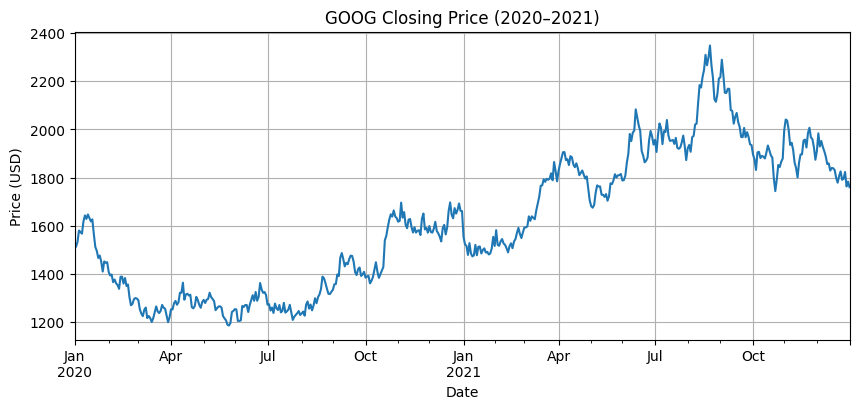

In [290]:
goog["close_price"].plot(
    title="GOOG Closing Price (2020–2021)",
    figsize=(10, 4)
)
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

7. Partial String Indexing
When your DataFrame is indexed by dates, you can slice rows simply by using slice notation inside the square brackets.
🔍 Concept
df["start":"end"] tells Pandas: “Give me all rows whose index timestamps lie between start and end (inclusive).”
The strings start and end can be as coarse as a year ("2020"), a month ("2021-01"), or as precise as a day ("2021-01-15").
Don’t write df["2020"] (no colon) to get rows—Pandas will look for a column named "2020" and throw a KeyError.


In [291]:
# 🧑‍💻 Step-by-Step in Jupyter
# Inspect your time series
goog.head()

,close_price
date,
2020-01-01,1515.651425
2020-01-02,1512.218041
2020-01-03,1532.563075
2020-01-06,1580.012143
2020-01-07,1573.402846


In [292]:
# Slice an entire year
# All of 2020
goog_2020 = goog["2020":"2020"]
print(goog_2020.shape)
goog_2020.head()

(262, 1)


,close_price
date,
2020-01-01,1515.651425
2020-01-02,1512.218041
2020-01-03,1532.563075
2020-01-06,1580.012143
2020-01-07,1573.402846


In [293]:
# Slice a quarter
# Q1 2021 (Jan–Mar)
q1_2021 = goog["2021-01":"2021-03"]
print(q1_2021.shape)
q1_2021.head()

(64, 1)


,close_price
date,
2021-01-01,1553.764305
2021-01-04,1522.708048
2021-01-05,1515.777651
2021-01-06,1478.708303
2021-01-07,1527.724860


💡 Tips & Tricks
Year only: df["YYYY":"YYYY"]
Year–Month: df["YYYY-MM":"YYYY-MM"]
Full date: df["YYYY-MM-DD":"YYYY-MM-DD"]
Supports inclusive slicing—the end date is included in the result.
Use this quick syntax whenever you need to pull out a calendar-aligned window without extra code.

8. Using .loc[] with Dates
Once your DataFrame is time-indexed, you can use the .loc[] accessor to select both rows (by date) and columns in one go.
🔍 Concept
df.loc[row_selector, col_selector] lets you specify:
row_selector: a single date, a date range, or a list of dates
col_selector: a column name, a list of names, or : for all columns
When you use a string or slice for row_selector on a DatetimeIndex, Pandas interprets it as date-based slicing.

In [294]:
# 🧑‍💻 Step-by-Step in Jupyter
# Closing price on January 15, 2021
goog.loc['2021-01-15', 'close_price']

np.float64(1512.576969308959)

In [295]:
# Select all columns for a single date
# All data on January 15, 2021 (returns a Series)
goog.loc['2021-01-15']

close_price    1512.576969
Name: 2021-01-15 00:00:00, dtype: float64

In [296]:
# Select a date range for one column
# Closing prices from Jan 1 to Jan 31, 2021
jan2021 = goog.loc['2021-01-01':'2021-01-31', 'close_price']
print(jan2021.shape)
jan2021.head()

(21,)


date
2021-01-01    1553.764305
2021-01-04    1522.708048
2021-01-05    1515.777651
2021-01-06    1478.708303
2021-01-07    1527.724860
Name: close_price, dtype: float64

In [297]:
# Select a date range and multiple columns
# (With a single-column DataFrame this returns a DataFrame anyway—here’s how it works if you had more columns.)
# Suppose you had columns ['open_price','close_price']
goog_sample = goog.copy()
goog_sample['open_price'] = goog_sample['close_price'] * 0.98  # dummy open

subset = goog_sample.loc['2021-06-01':'2021-06-15', ['open_price', 'close_price']]
subset.head()

,open_price,close_price
date,,
2021-06-01,1751.679972,1787.428543
2021-06-02,1753.414492,1789.198461
2021-06-03,1771.755148,1807.913416
2021-06-04,1824.062448,1861.288213
2021-06-07,1859.969877,1897.928446


💡 Tips & Tricks
Mix & match: combine precise row and column selections in one statement.
Slicing is inclusive of the end date.
Using .loc[] is the most explicit and versatile way to index time-based data when you need both rows and columns.

9. Using .asfreq() to Set Frequency
When you load a time series, its index may not carry explicit frequency information—even if the data are regularly spaced (e.g., every business day). The .asfreq() method lets you declare the frequency you expect, filling in any gaps with NaN.
🔍 Concept
df.asfreq(freq) returns a new Series/DataFrame having the specified frequency (freq) on its DatetimeIndex.
Upsampling (to a higher frequency) will introduce new timestamps with missing values.
Downsampling (to a lower frequency) will drop intermediate timestamps.


In [298]:
# 🧑‍💻 Example in Jupyter
# Assume goog has a DatetimeIndex of business days (freq='B')
# 1️⃣ Convert to a daily frequency (calendar days)
goog_daily = goog.asfreq('D')

# Inspect the first 10 rows
print(goog_daily.head(10))

# Check that Pandas now recognizes a daily frequency
print("Frequency attribute:", goog_daily.index.freq)

# Why? The original goog DataFrame only had entries for business days. By calling .asfreq('D'), 
# we told Pandas to expect a value every calendar day—so weekends appear with NaN.

            close_price
date                   
2020-01-01  1515.651425
2020-01-02  1512.218041
2020-01-03  1532.563075
2020-01-04          NaN
2020-01-05          NaN
2020-01-06  1580.012143
2020-01-07  1573.402846
2020-01-08  1566.821712
2020-01-09  1617.092022
2020-01-10  1642.720819
Frequency attribute: <Day>


In [299]:
# 🔄 Downsampling with .asfreq()
# You can also downsample by specifying a lower frequency:
# Keep only month-ends (drop all other days)

goog_monthly_end = goog_daily.asfreq('M')
goog_monthly_end.head()

# Result: Only the last calendar day of each month is retained; all other rows are dropped.
# Forward fill missing values
goog_monthly_end = goog_monthly_end.ffill()

goog_monthly_end.head()


/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2313864075.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  goog_monthly_end = goog_daily.asfreq('M')


,close_price
date,
2020-01-31,1448.515094
2020-02-29,1448.515094
2020-03-31,1219.677896
2020-04-30,1283.067523
2020-05-31,1283.067523


10. 📈 Upsampling Introduces Missing Values
When you increase the frequency of a time series—known as upsampling—Pandas will insert new timestamps at the higher frequency. Because your original data only had values at the lower frequency, all of these new timestamps will carry NaN until you explicitly fill or interpolate them.
📝 Explanation
Upsampling: expanding to a finer-grained time grid (e.g. daily → hourly)
Gaps: new timestamps appear where no original data existed
Detection: use .isna() or .isnull() to find these missing entries


In [300]:
# 🧑‍💻 Example in Jupyter
# Start with the business-day series
goog_biz = goog.asfreq('B')      # has values only on business days

# Upsample to hourly frequency
goog_hourly = goog_biz.asfreq('H')

# Inspect the first 10 rows
print(goog_hourly.head(10))
# Count how many hourly slots are missing
num_missing = goog_hourly['close_price'].isna().sum()
print("Missing hourly data points:", num_missing)

                     close_price
date                            
2020-01-01 00:00:00  1515.651425
2020-01-01 01:00:00          NaN
2020-01-01 02:00:00          NaN
2020-01-01 03:00:00          NaN
2020-01-01 04:00:00          NaN
2020-01-01 05:00:00          NaN
2020-01-01 06:00:00          NaN
2020-01-01 07:00:00          NaN
2020-01-01 08:00:00          NaN
2020-01-01 09:00:00          NaN
Missing hourly data points: 16998


/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/3757876725.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  goog_hourly = goog_biz.asfreq('H')


💡 Key Takeaways
Upsampling without filling will introduce NaN for all new timestamps.
Always inspect and fill or interpolate missing values (e.g., .ffill(), .bfill(), .interpolate()) before using upsampled data in models or visualizations.
Use missing-value detection (.isna(), .isnull()) to quantify gaps before proceeding.

11. 🏢 Switching to Business Day Frequency
When working with financial time series, you often want to align your data strictly to business days (i.e., Monday through Friday, excluding weekends and market holidays). Pandas lets you do this easily with the 'B' frequency alias in .asfreq().
🔍 Concept
Business-day frequency ('B'): includes only weekdays (Mon–Fri).
asfreq('B') on a daily-indexed series will drop weekend entries.
If your series wasn’t originally daily, it will add or remove rows to match the business-day calendar.


In [301]:
# 🧑‍💻 Step-by-Step in Jupyter
# Start from a daily series
# Suppose we’ve already made a daily series
goog_daily = goog.asfreq('D')
print("Original daily index sample:")
print(goog_daily.head(7))

# Convert to business-day frequency
goog_biz = goog_daily.asfreq('B')
print("After applying business-day freq:")
print(goog_biz.head(7))

#What changed?
#Entries for 2020-01-04 and 2020-01-05 (weekend) have been removed.
#The index now only contains business days, matching typical trading calendars.


Original daily index sample:
            close_price
date                   
2020-01-01  1515.651425
2020-01-02  1512.218041
2020-01-03  1532.563075
2020-01-04          NaN
2020-01-05          NaN
2020-01-06  1580.012143
2020-01-07  1573.402846
After applying business-day freq:
            close_price
date                   
2020-01-01  1515.651425
2020-01-02  1512.218041
2020-01-03  1532.563075
2020-01-06  1580.012143
2020-01-07  1573.402846
2020-01-08  1566.821712
2020-01-09  1617.092022


💡 Key Takeaways
Use asfreq('B') to align your series to business days.
This automatically drops weekend rows (and any non-business days if you subsequently filter by holiday calendars).
Ensures your time series matches stock market schedules before analysis or modeling.

12. 🕵️ Identifying Missing Business Days
After aligning your series to a business-day calendar with .asfreq('B'), any dates on which trading didn’t occur (holidays, unexpected closures) will appear with NaN. Detecting these gaps is crucial before filling or interpolating your series.
🔍 Concept
Missing values in a business-day–indexed series indicate non-trading days such as market holidays.
Use boolean indexing with .isna() (or .isnull()) to locate these dates.


In [302]:
# 🧑‍💻 Example in Jupyter
# Assume goog_biz is your business-day–indexed DataFrame
import pandas as pd

# Identify rows with missing close_price
missing_biz = goog_biz[goog_biz['close_price'].isna()]

# View the first few missing entries
print(missing_biz.head())
# How many business days have no trading data?
print("Number of missing business days:", missing_biz.shape[0])

Empty DataFrame
Columns: [close_price]
Index: []
Number of missing business days: 0


💡 Why This Matters
Holidays & Closures: Stock markets close on specific holidays—these will show as NaN if you align to all business days.
Data Integrity: Before resampling or modeling, decide how to handle these days (e.g., forward-fill last price, drop them, or interpolate).
Downstream Analysis: Ensures your metrics (returns, moving averages) aren’t skewed by unexpected gaps.
With this step, you’ve mastered how to detect and prepare for non-trading days in a business-day series.

## 🧪 Exercise: Structuring Time Series – Indexing & Visualizing Air Quality Trends
In this exercise, you’ll practice converting raw date strings into a time-aware DataFrame, slicing by dates, and visualizing multiple pollutants in subplots.
We’ll be using a simulated air quality dataset with daily readings for ozone, PM2.5, and CO spanning the year 2023. You can download it here:
📂 Download air_quality_trends_simulated.csv

In [303]:
# Load the dataset
import pandas as pd
df = pd.read_csv("air_quality_trends_simulated.csv")

In [304]:
# Convert the date column to datetime and set it as the index:
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

In [305]:
# Inspect the DataFrame using .info() and .head() to confirm the index and dtypes.

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2023-01-01 to 2023-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ozone   365 non-null    float64
 1   pm25    365 non-null    float64
 2   co      365 non-null    float64
dtypes: float64(3)
memory usage: 11.4 KB


In [306]:
df.head()

,ozone,pm25,co
date,,,
2023-01-01,57.440675,18.758119,0.951169
2023-01-02,65.759468,26.725029,0.814028
2023-01-03,60.138169,16.970760,0.801403
2023-01-04,57.244159,32.121332,0.686995
2023-01-05,51.182740,25.700751,0.945567


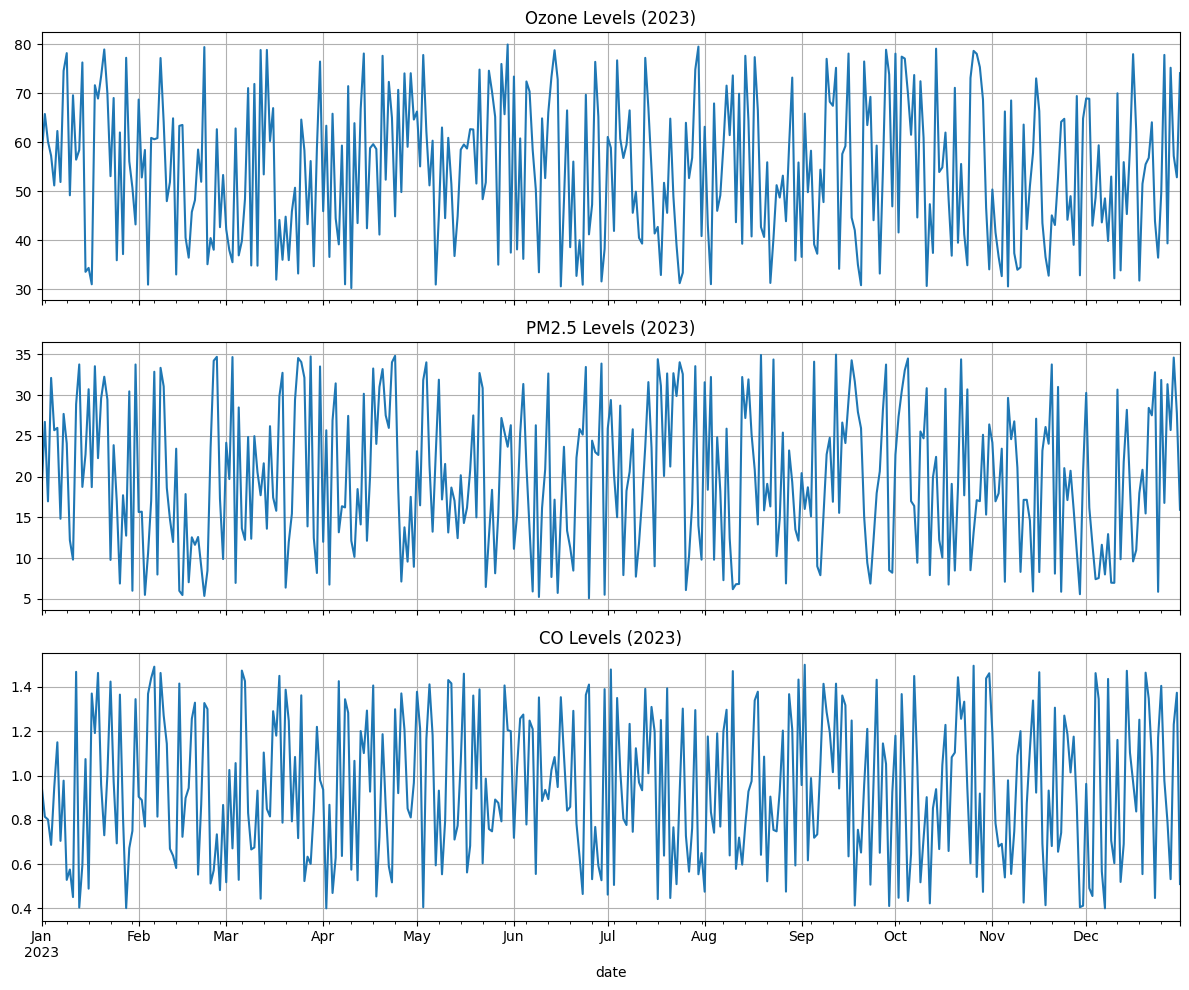

In [307]:
# Plot the full-year time series for each pollutant in separate subplots:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)
df["ozone"].plot(ax=axes[0], title="Ozone Levels (2023)")
df["pm25"].plot(ax=axes[1], title="PM2.5 Levels (2023)")
df["co"].plot(ax=axes[2], title="CO Levels (2023)")
plt.tight_layout()
plt.show()

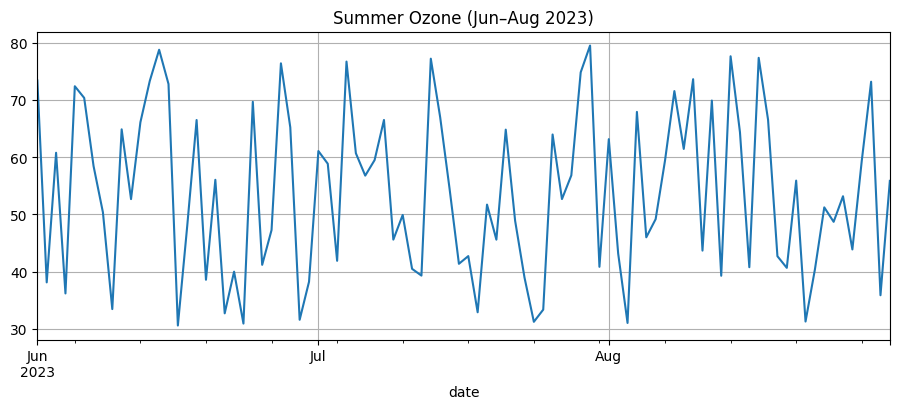

In [308]:
# Use partial string indexing (without .loc) to extract and plot the summer months (June–August 2023) for ozone only:

summer_ozone = df["2023-06":"2023-08"]["ozone"]
summer_ozone.plot(title="Summer Ozone (Jun–Aug 2023)")
plt.show()

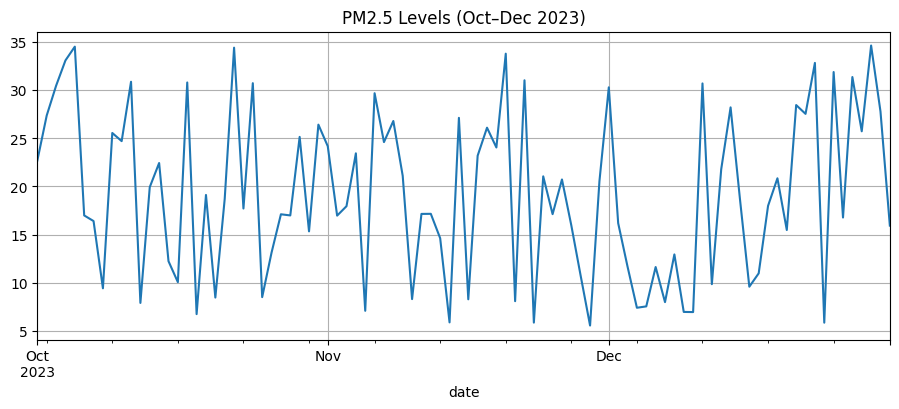

In [309]:
pm25_Q4 = df["2023-10":"2023-12"]["pm25"]
pm25_Q4.plot(title="PM2.5 Levels (Oct–Dec 2023)")
plt.show()

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2236661454.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  co_monthly = df["co"].resample("M").mean()


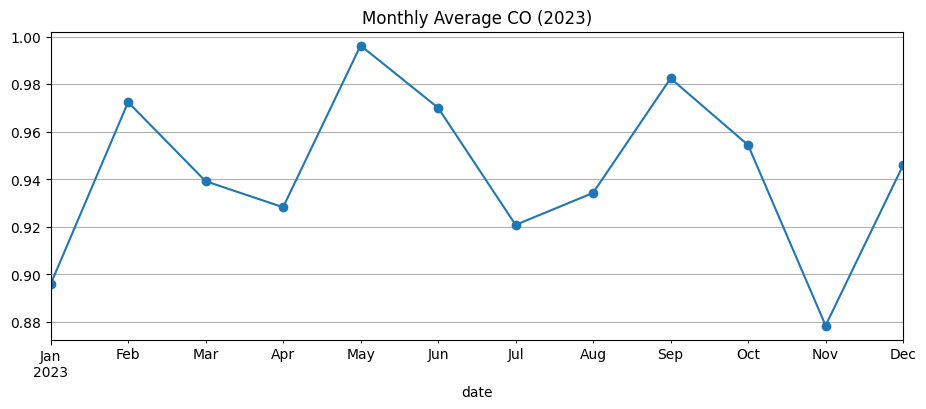

In [310]:
# Resample to monthly averages and plot the result for CO:
co_monthly = df["co"].resample("M").mean()
co_monthly.plot(marker="o", title="Monthly Average CO (2023)")
plt.show()

In [311]:
# Set a business-day frequency on the ozone series and count missing values (holidays):
oz_biz = df["ozone"].asfreq("B")
missing_holidays = oz_biz.isna().sum()
print("Missing business days in ozone data:", missing_holidays)

Missing business days in ozone data: 0


## 🧪 Exercise: Set and Change Time Series Frequency
In this exercise, you’ll practice declaring and transforming the observation frequency of a time-series DataFrame. You’ll work with the same simulated air quality dataset of daily readings for 2023, and:
Explicitly set a calendar-daily frequency
Upsample to hourly and fill in missing measurements
Downsample to monthly averages
Align to business-day frequency and identify gaps
📂 Dataset
Use the simulated air quality file: air_quality_trends_simulated.csv
(This contains daily ozone, pm25, and co for every day in 2023.)

In [312]:
# Load & Index
# Load the CSV into df with pd.read_csv().
# Convert "date" to datetime64 and set it as the index.


df = pd.read_csv("air_quality_trends_simulated.csv")

In [313]:
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

In [314]:
# Set Explicit Daily Frequency
# Use .asfreq('D') on df to declare a true calendar-daily series.
# Assign to df_daily.

df_daily = df.asfreq("D")

In [315]:
# Upsample to Hourly
# From df_daily, create df_hourly via .asfreq('H').
# Use .ffill() to forward-fill missing values at each hour.

df_hourly = df_daily.asfreq("h").ffill()

In [316]:
# Downsample to Monthly Means
# On df_daily, compute df_monthly = df_daily.resample('M').mean().
# This yields one row per month with average pollutant levels.

df_monthly = df_daily.resample("M").mean()

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/938273563.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_daily.resample("M").mean()


In [317]:
# Align to Business-Day Frequency
# Apply .asfreq('B') on df_daily to get df_biz.
# Count how many business-day entries are NaN in the ozone column.

df_biz = df_daily.asfreq("B")
missing_biz_days = df_biz["ozone"].isna().sum()
print("Missing business days in ozone data:", missing_biz_days)

Missing business days in ozone data: 0


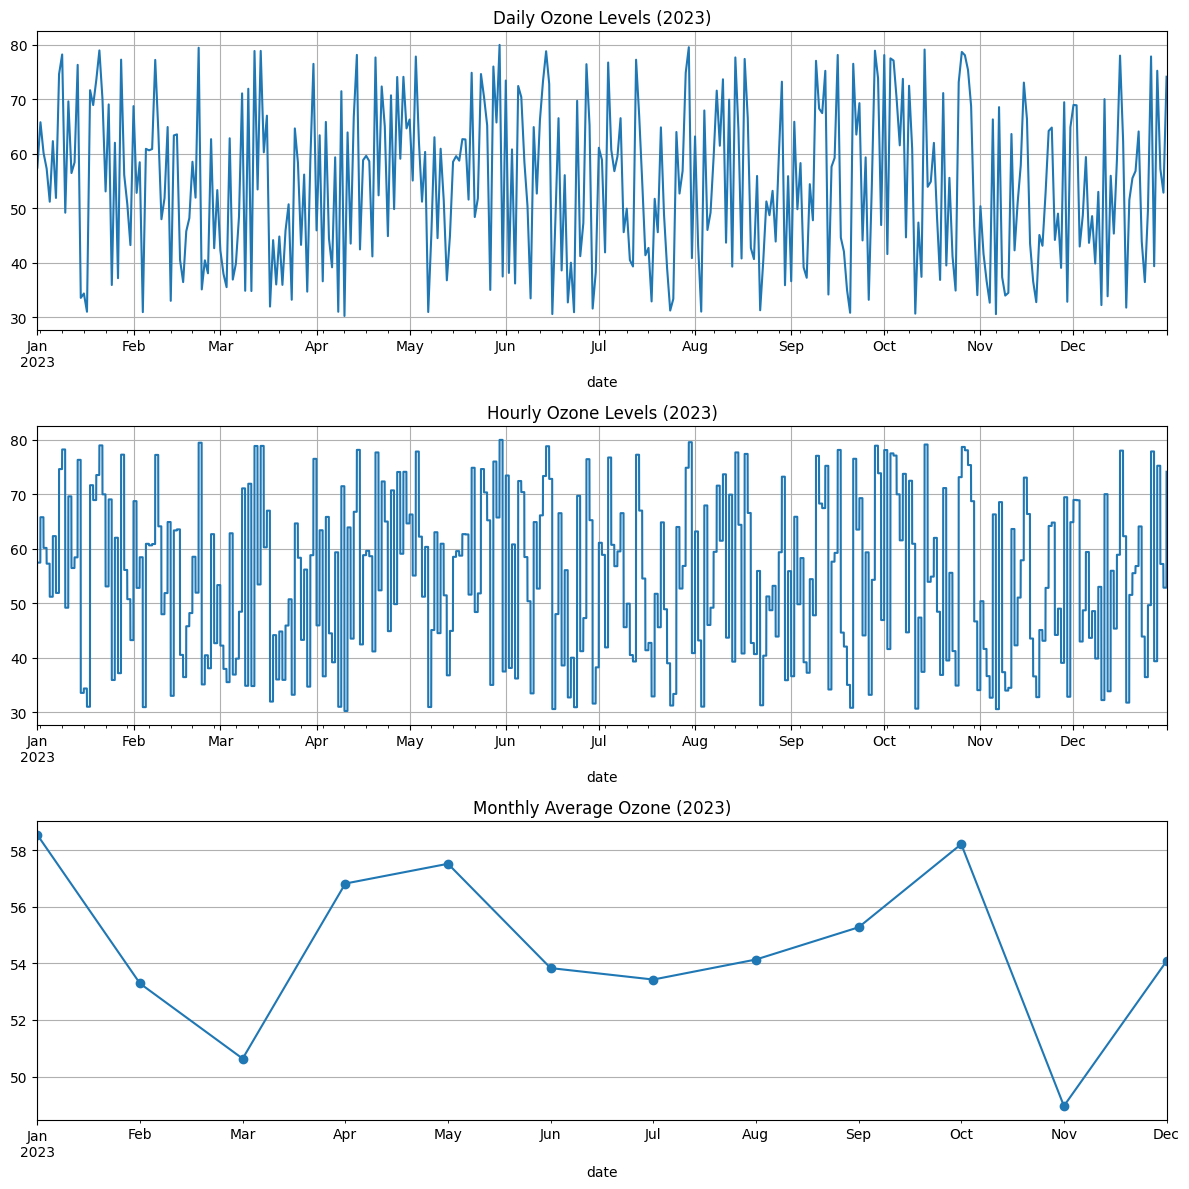

In [318]:
# Visualize the Results
# Plot three subplots (stacked vertically) in one figure:
# Daily series (df_daily["ozone"])
# Hourly series (df_hourly["ozone"])
# Monthly average (df_monthly["ozone"])

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12), sharex=False)
df_daily["ozone"].plot(ax=axes[0], title="Daily Ozone Levels (2023)")
df_hourly["ozone"].plot(ax=axes[1], title="Hourly Ozone Levels (2023)")
df_monthly["ozone"].plot(ax=axes[2], marker="o", title="Monthly Average Ozone (2023)")
plt.tight_layout()

## Lags, Changes, and Returns for Stock Price Series
1. Create lags and leads with .shift().
2. Compute absolute changes with .diff().
3. Compute simple returns (and log returns) — 1-period and multi-period.
4. Handle the NaN edges introduced by shifting.
5. Plot and sanity-check your transformations.

In [319]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If the CSV is next to your notebook:
goog = pd.read_csv("goog_simulated.csv", parse_dates=["date"], index_col="date")

goog.info()
goog.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 523 entries, 2020-01-01 to 2021-12-31
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   close_price  523 non-null    float64
dtypes: float64(1)
memory usage: 8.2 KB


,close_price
date,
2020-01-01,1515.651425
2020-01-02,1512.218041
2020-01-03,1532.563075
2020-01-06,1580.012143
2020-01-07,1573.402846


In [321]:
# 1) Lags & Leads with .shift()
# Why: To compare today’s price to a prior (or future) date, you need aligned series.

# Original series
price = goog["close_price"]

# 1-day lag (yesterday's price aligned to today)
goog["lag_1d"]  = price.shift(1)

# 1-day lead (tomorrow's price aligned to today)
goog["lead_1d"] = price.shift(-1)

goog[["close_price", "lag_1d", "lead_1d"]].head(3)

# Note: The first row of lag_1d and the last row of lead_1d will be NaN—that’s expected.

,close_price,lag_1d,lead_1d
date,,,
2020-01-01,1515.651425,NaN,1512.218041
2020-01-02,1512.218041,1515.651425,1532.563075
2020-01-03,1532.563075,1512.218041,1580.012143


In [322]:
# 2) Absolute Changes with .diff()
# Why: Sometimes you want the raw change in dollars, not a percentage.

# Change since previous trading day
goog["diff_1d"] = price.diff()          # equivalent to price - price.shift(1)

# Quick check: diff vs manual
check = (goog["diff_1d"] - (price - goog["lag_1d"])).abs().max()
print("Max diff between methods:", check)
goog[["close_price", "lag_1d", "diff_1d"]].head(4)

Max diff between methods: 0.0


,close_price,lag_1d,diff_1d
date,,,
2020-01-01,1515.651425,NaN,NaN
2020-01-02,1512.218041,1515.651425,-3.433384
2020-01-03,1532.563075,1512.218041,20.345035
2020-01-06,1580.012143,1532.563075,47.449068


In [325]:
# 3) Simple Returns (1-Period)
# Why: Returns normalize price changes so series are comparable.
# Manual (factor → percent):
# Growth factor today vs yesterday
goog["factor_1d"] = price / goog["lag_1d"]

# Simple return in %
goog["ret_1d_pct"] = (goog["factor_1d"] - 1) * 100
goog[["close_price", "lag_1d", "factor_1d", "ret_1d_pct"]].head(5)
# Built-in (.pct_change()):
goog["ret_1d_pct_builtin"] = price.pct_change() * 100

# Sanity check — they should match (up to float rounding)
mismatch = (goog["ret_1d_pct"] - goog["ret_1d_pct_builtin"]).abs().max()
print("Max mismatch (percentage points):", mismatch)
# Log returns (optional):
goog["ret_1d_log"] = np.log(price / goog["lag_1d"])
goog[["ret_1d_pct", "ret_1d_log"]].head(5)
# Tip: Simple returns are intuitive for reporting; log returns add nicely over time and are common in modeling.

Max mismatch (percentage points): 0.0


,ret_1d_pct,ret_1d_log
date,,
2020-01-01,NaN,NaN
2020-01-02,-0.226529,-0.002268
2020-01-03,1.345377,0.013364
2020-01-06,3.096060,0.030491
2020-01-07,-0.418307,-0.004192


In [326]:
# 4) Multi-Period Returns
# Why: Measure change over longer horizons (e.g., weekly ≈ 5 business days).
# 5-day lag and 5-day simple return (%)
goog["lag_5d"]      = price.shift(5)
goog["ret_5d_pct"]  = (price / goog["lag_5d"] - 1) * 100

# Built-in: pct_change over 5 periods
goog["ret_5d_pct_builtin"] = price.pct_change(periods=5) * 100

# Check
(goog["ret_5d_pct"] - goog["ret_5d_pct_builtin"]).abs().max()

np.float64(0.0)

In [327]:
# 5) Cumulative Growth / Base-100 Index (optional but useful)
# 
# Why: Visualize growth from a common baseline.
# Normalize price to 100 at the first valid point
goog["price_index_100"] = price / price.iloc[0] * 100

# Or cumulate simple daily returns (as factors)
goog["cum_growth_factor"] = (1 + price.pct_change()).cumprod()
goog[["price_index_100", "cum_growth_factor"]].head(10)

,price_index_100,cum_growth_factor
date,,
2020-01-01,100.000000,NaN
2020-01-02,99.773471,0.997735
2020-01-03,101.115801,1.011158
2020-01-06,104.246406,1.042464
2020-01-07,103.810337,1.038103
2020-01-08,103.376125,1.033761
2020-01-09,106.692871,1.066929
2020-01-10,108.383814,1.083838
2020-01-13,107.420337,1.074203


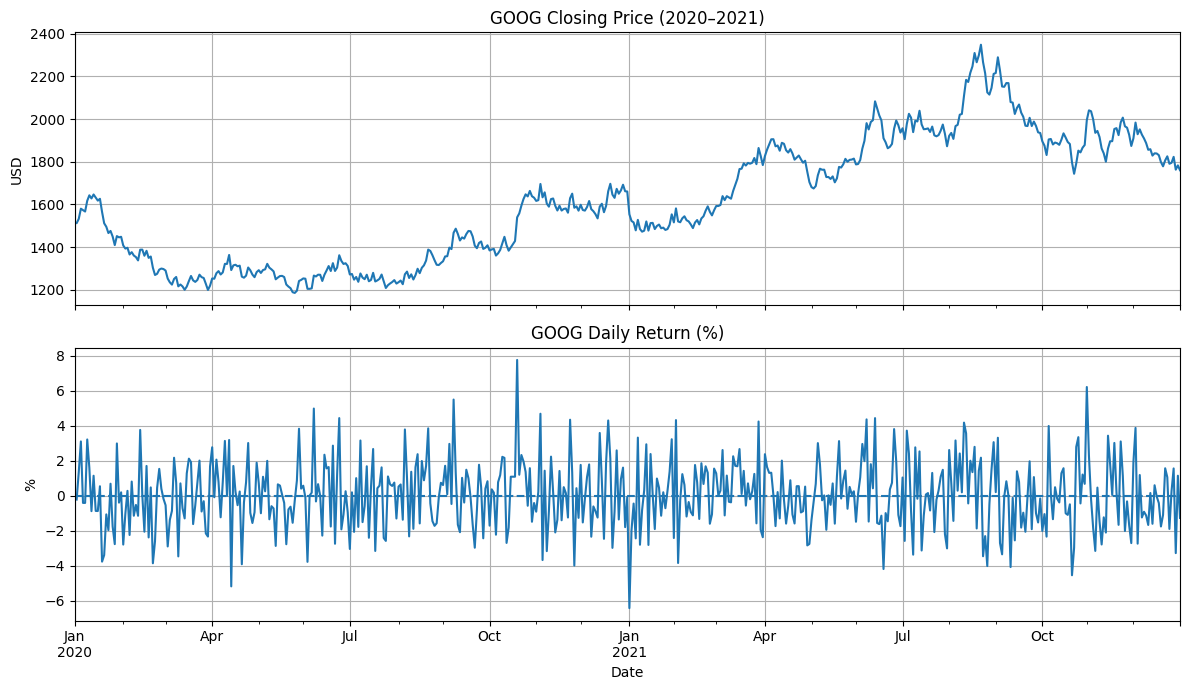

In [328]:
# 6) Plot: Price vs. Daily Returns
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

price.plot(ax=axes[0], title="GOOG Closing Price (2020–2021)")
axes[0].set_ylabel("USD"); axes[0].grid(True)

goog["ret_1d_pct"].plot(ax=axes[1], title="GOOG Daily Return (%)")
axes[1].axhline(0, ls="--")
axes[1].set_ylabel("%"); axes[1].set_xlabel("Date"); axes[1].grid(True)

plt.tight_layout(); plt.show()

7) Common Pitfalls & Gotchas

- Edge NaNs: Shifts create NaNs at the edges. Use .dropna() before stats/plots if needed:
returns_clean = goog["ret_1d_pct"].dropna()
- Column vs. index ambiguity: df["2020"] tries to select a column named "2020". For date slices use:
- Slice syntax: df["2020":"2020"]
Or explicit: df.loc["2020"]
- Multi-period interpretation: periods=5 means “5 index steps,” not calendar days—on business-day data it’s ~1 week.

Key Takeaways
- Use .shift() for time alignment (lags/leads).
- Use .diff() for absolute changes; .pct_change() for returns.
- The periods parameter generalizes these to multi-period windows.
- Always inspect NaNs introduced by shifting before downstream analysis.
- Visual checks (price vs returns) help catch mistakes early.


1) Create Lags & Leads
Create a price Series: price = goog["close_price"].
Create a 1-day lag column: yesterday’s price aligned to today (shift(1)).
Create a 1-day lead column: tomorrow’s price aligned to today (shift(-1)).
Count the NaNs introduced at the edges.

2) Absolute Changes with .diff()
Add diff_1d = change vs. prior day.
Verify it matches price - lag_1d (compute the max absolute difference).


3) Daily Simple Returns (two ways)
Manual: growth factor = price / lag_1d, then return% = (factor - 1) * 100.
Built-in: price.pct_change() * 100.
Compare the two (max absolute difference).

## Compare the Performance of Stocks, Bonds, Gold & Oil

- Loading and indexing multi-asset time series.
- Normalizing series to a common base (e.g., 100) for fair comparison.- 
- Resampling daily data to monthly to compute returns.
- Building a simple performance summary.

In [338]:
# 1) Load & Prepare
import pandas as pd
import matplotlib.pyplot as plt

# Load and time-index
df = pd.read_csv("assets_simulated.csv", parse_dates=["date"], index_col="date")
df.head()

,stocks,bonds,gold,oil
date,,,,
2020-01-01,988.015672,99.901858,1489.133679,57.871892
2020-01-02,999.505412,99.772249,1488.372487,58.077106
2020-01-03,1002.971545,99.913461,1481.619016,58.823458
2020-01-06,986.236137,100.114157,1485.424203,60.141394
2020-01-07,980.034995,99.769334,1471.533018,59.647521


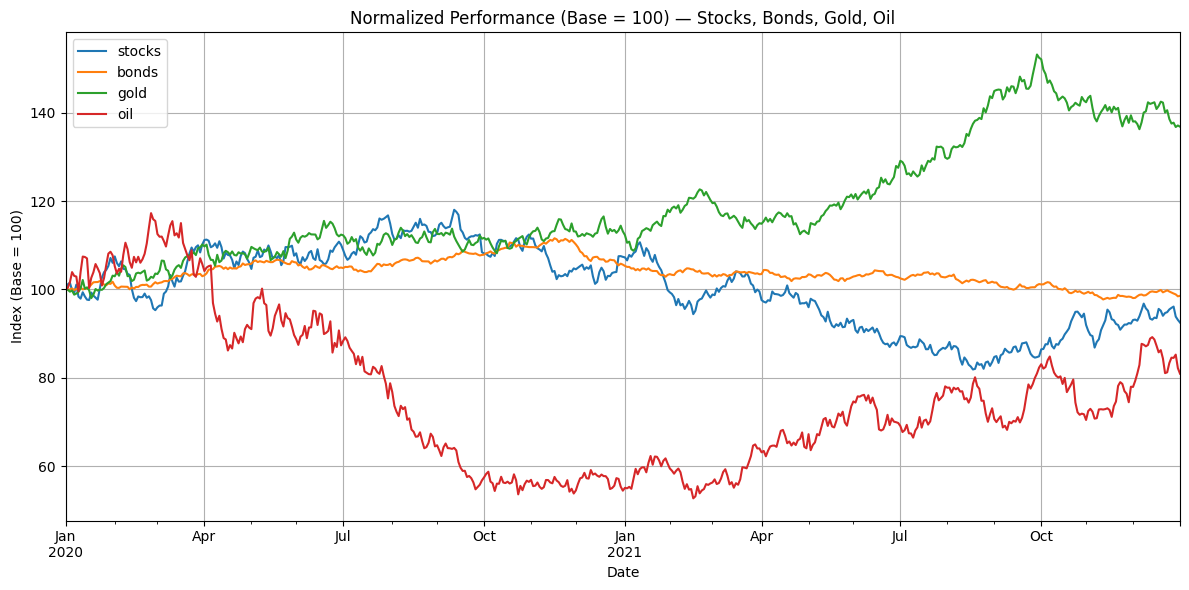

In [339]:
# 2) Normalize (Base = 100)
# Why? Raw prices aren’t comparable (different scales). Normalizing shows relative growth.

normalized = df / df.iloc[0] * 100
ax = normalized.plot(figsize=(12, 6), title="Normalized Performance (Base = 100) — Stocks, Bonds, Gold, Oil")
ax.set_xlabel("Date"); ax.set_ylabel("Index (Base = 100)"); ax.grid(True)
plt.tight_layout(); plt.show()

# You should see all four lines start at 100 and diverge over time.


In [340]:
# 3) Resample to Monthly & Compute Returns
# Why? Monthly returns make cross-asset comparisons cleaner and reduce noise.

# Month-end 'closes'
monthly_last = df.resample("M").last()

# Month-over-month returns (%)
monthly_returns = monthly_last.pct_change() * 100
monthly_returns.head()

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/4250669782.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_last = df.resample("M").last()


,stocks,bonds,gold,oil
date,,,,
2020-01-31,NaN,NaN,NaN,NaN
2020-02-29,-10.103306,-0.111341,0.458980,7.200571
2020-03-31,15.572503,1.334084,6.342206,-8.436584
2020-04-30,-3.716807,2.638529,-1.800704,-13.612029
2020-05-31,1.484728,0.449488,4.316225,-1.817217


In [341]:
# 4) Quick Performance Summary
# Cumulative return over the full period (%)
cum_ret = (df.iloc[-1] / df.iloc[0] - 1) * 100
print("Cumulative return (%):")
print(cum_ret.round(2))

# Average monthly return and monthly volatility
summary = pd.DataFrame({
    "avg_monthly_return_%": monthly_returns.mean(),
    "monthly_vol_%": monthly_returns.std()
}).round(2)
summary

Cumulative return (%):
stocks    -7.49
bonds     -1.45
gold      36.83
oil      -19.06
dtype: float64


,avg_monthly_return_%,monthly_vol_%
stocks,-0.44,5.72
bonds,-0.13,1.49
gold,1.31,4.05
oil,-0.77,9.81


/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/3445284067.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (normalized.resample("M").last()).plot(


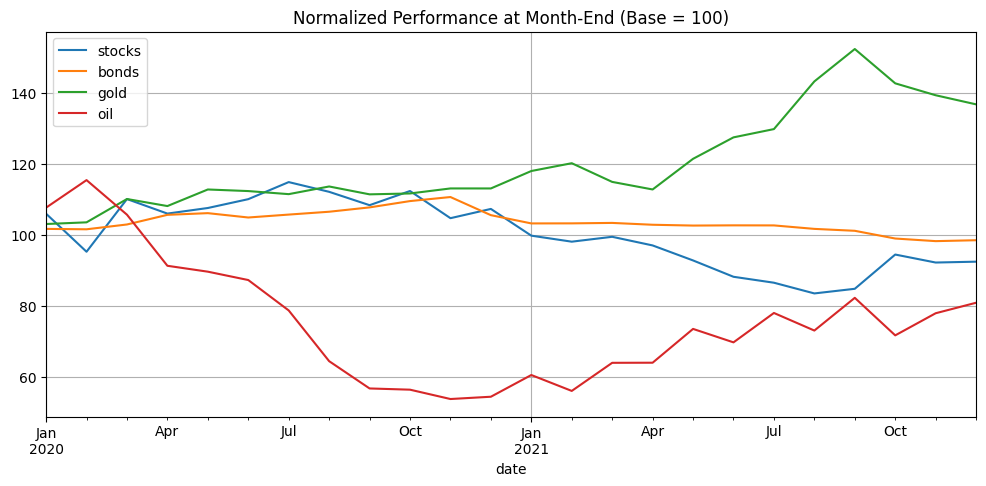

In [342]:
# 5) (Optional) Side-by-Side Plot at Monthly Frequency
(normalized.resample("M").last()).plot(
    figsize=(12, 5),
    title="Normalized Performance at Month-End (Base = 100)"
)
plt.grid(True); plt.show()

## Comparing Stocks to a Benchmark

- Normalizing series to a common base (fair performance comparison).
- Computing active returns (excess vs. benchmark).
- Estimating rolling correlation and rolling beta.
- Visualizing scatter + OLS beta (market sensitivity).

In [344]:
# 1) Load & Inspect
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("benchmark_stocks_simulated.csv", parse_dates=["date"], index_col="date")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 523 entries, 2020-01-01 to 2021-12-31
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DJIA     523 non-null    float64
 1   Stock_A  523 non-null    float64
 2   Stock_B  523 non-null    float64
 3   Stock_C  523 non-null    float64
dtypes: float64(4)
memory usage: 20.4 KB


,DJIA,Stock_A,Stock_B,Stock_C
date,,,,
2020-01-01,28546.863763,121.387060,81.585016,228.706871
2020-01-02,28401.377734,121.111576,80.194110,221.391984
2020-01-03,28416.887847,122.507099,79.304360,226.247382
2020-01-06,28553.462888,124.274453,79.087044,226.609147
2020-01-07,28304.094722,122.843393,77.335288,224.941193


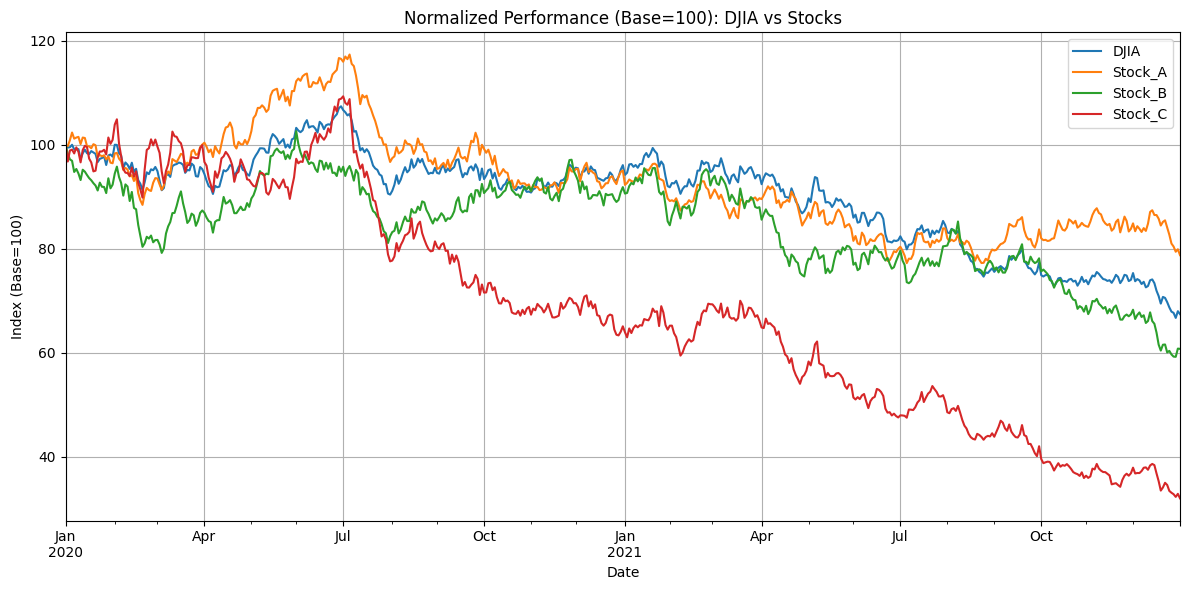

In [345]:
# 2) Normalize to a Common Start (Base = 100)
# Why? Raw prices vary by scale. Normalizing lets you compare relative performance.
normalized = df / df.iloc[0] * 100

ax = normalized.plot(figsize=(12, 6),
                     title="Normalized Performance (Base=100): DJIA vs Stocks")
ax.set_xlabel("Date"); ax.set_ylabel("Index (Base=100)"); ax.grid(True)
plt.tight_layout(); plt.show()


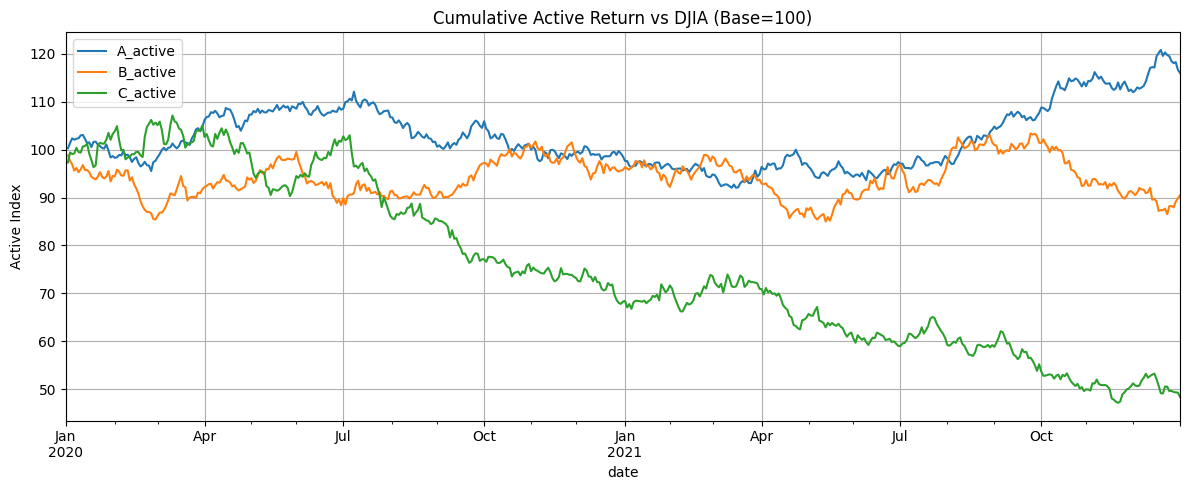

In [346]:
# # Daily % returns
rets = df.pct_change() * 100

# Active return = stock return − benchmark return
active = pd.DataFrame({
    "A_active": rets["Stock_A"] - rets["DJIA"],
    "B_active": rets["Stock_B"] - rets["DJIA"],
    "C_active": rets["Stock_C"] - rets["DJIA"],
}, index=rets.index)

# Cumulative active index (Base=100)
cum_active = (1 + active/100).cumprod() * 100

cum_active.plot(figsize=(12, 5), title="Cumulative Active Return vs DJIA (Base=100)")
plt.ylabel("Active Index"); plt.grid(True); plt.tight_layout(); plt.show()

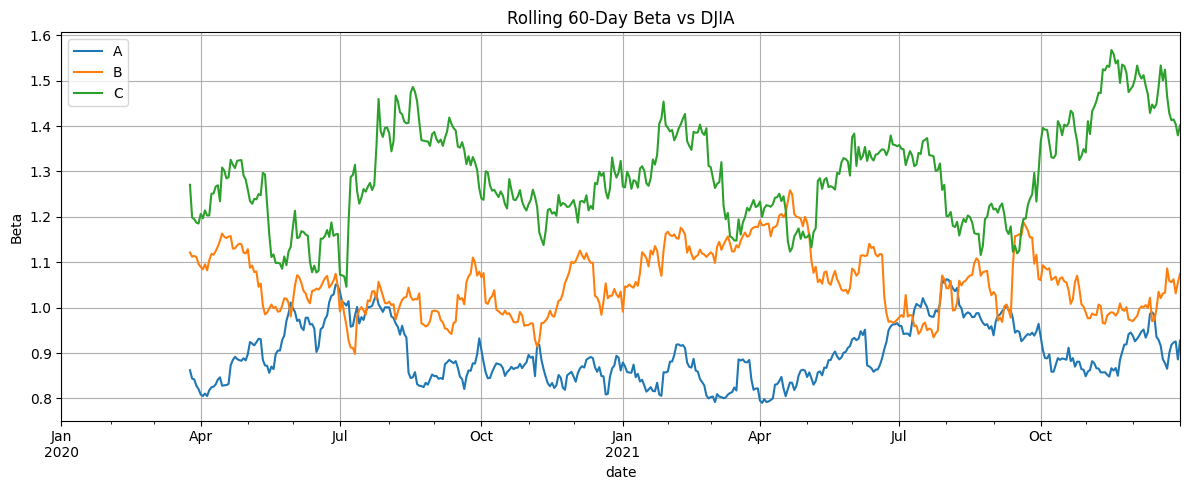

In [349]:
# 4) Rolling 60-Day Correlation & Beta
# Beta ≈ cov(stock, market) / var(market) over a rolling window.

window = 60

# Correlations
corr_A = rets["Stock_A"].rolling(window).corr(rets["DJIA"])
corr_B = rets["Stock_B"].rolling(window).corr(rets["DJIA"])
corr_C = rets["Stock_C"].rolling(window).corr(rets["DJIA"])

# Rolling beta helper
def rolling_beta(x, y, w):
    cov = x.rolling(w).cov(y)
    var = y.rolling(w).var()
    return cov / var

beta_A = rolling_beta(rets["Stock_A"], rets["DJIA"], window)
beta_B = rolling_beta(rets["Stock_B"], rets["DJIA"], window)
beta_C = rolling_beta(rets["Stock_C"], rets["DJIA"], window)

# Plot rolling beta
pd.concat([beta_A.rename("A"), beta_B.rename("B"), beta_C.rename("C")], axis=1)\
  .plot(figsize=(12,5), title="Rolling 60-Day Beta vs DJIA")
plt.ylabel("Beta"); plt.grid(True); plt.tight_layout(); plt.show()




Reading beta:
~1.0 → moves about the same as the market
1.0 → more volatile/sensitive than market
<1.0 → less sensitive/“defensive”

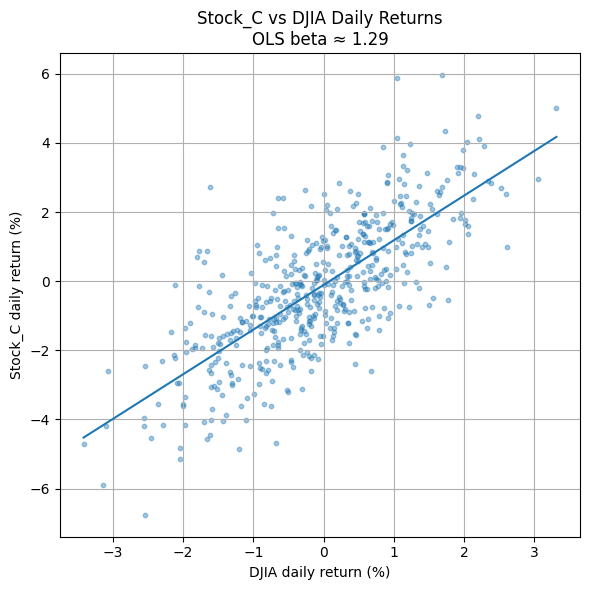

In [350]:
# 5) Scatter Plot & OLS Beta (Stock_C example)
import numpy as np

x = rets["DJIA"].dropna()
y = rets["Stock_C"].loc[x.index]

# OLS slope is the beta estimate
slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=10, alpha=0.4)
xline = np.linspace(x.min(), x.max(), 100)
plt.plot(xline, intercept + slope*xline)
plt.title(f"Stock_C vs DJIA Daily Returns\nOLS beta ≈ {slope:.2f}")
plt.xlabel("DJIA daily return (%)")
plt.ylabel("Stock_C daily return (%)")
plt.grid(True); plt.tight_layout(); plt.show()

## Changing the Time Series Frequency: Resampling

Part 1: Convert Monthly → Weekly data
- When you “change frequency,” you’re either:
- Downsampling (higher → lower freq, e.g., daily → monthly): you aggregate.
- Upsampling (lower → higher freq, e.g., monthly → weekly): you create new timestamps and must fill or interpolate values.

- Monthly → Weekly is upsampling. Your choice of fill depends on what the monthly number means.

⚖️ Pick the right strategy

- End-of-month level (e.g., price at month-end): use forward fill into the weeks.
- Monthly average (e.g., average rate for the month): use time interpolation to smooth between months.
- Monthly total (e.g., energy consumed in the month): convert to a daily rate, then sum into weeks.

Below are patterns for each, using the simulated assets dataset.

In [351]:
import pandas as pd

# Daily prices for 2020–2021
df = pd.read_csv("assets_simulated.csv", parse_dates=["date"], index_col="date")

# Build a clean MONTHLY series (month-end close) for one asset
price_m = df["stocks"].resample("M").last().rename("stocks_EOM")
price_m.head()

# We now have one value per month at the month end.

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2239413315.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  price_m = df["stocks"].resample("M").last().rename("stocks_EOM")


date
2020-01-31    1047.517884
2020-02-29     941.683948
2020-03-31    1088.327708
2020-04-30    1047.876668
2020-05-31    1063.434786
Freq: ME, Name: stocks_EOM, dtype: float64

In [352]:
# A) Monthly level → Weekly (forward-fill)
# Use this when the monthly value represents a level at month-end (e.g., closing price, headcount snapshot).

# Create Friday-anchored weekly index, fill forward the last known monthly value
stocks_w_ffill = price_m.resample("W-FRI").ffill()
stocks_w_ffill.head(8)

# W-FRI anchors weeks to Friday, common for financial data.
# New weekly timestamps appear; values are carried forward from the previous month-end.

date
2020-01-31    1047.517884
2020-02-07    1047.517884
2020-02-14    1047.517884
2020-02-21    1047.517884
2020-02-28    1047.517884
2020-03-06     941.683948
2020-03-13     941.683948
2020-03-20     941.683948
Freq: W-FRI, Name: stocks_EOM, dtype: float64

In [354]:
# B) Monthly average → Weekly (time interpolation)
# If the monthly value is meant to represent an average over the month, linear time interpolation often makes more sense than a step function.

# Interpolate between month-ends on a weekly grid
stocks_w_interp = price_m.resample("W-FRI").interpolate(method="time")
stocks_w_interp.head(8)

# method="time" respects the spacing of dates (not just row counts).
# Produces a smooth week-by-week path.

date
2020-01-31    1047.517884
2020-02-07    1050.903856
2020-02-14    1054.289828
2020-02-21    1057.675800
2020-02-28    1061.061772
2020-03-06    1064.447744
2020-03-13    1067.833716
2020-03-20    1071.219689
Freq: W-FRI, Name: stocks_EOM, dtype: float64

In [355]:
# C) Monthly total → Weekly (rate → sum)
# If the monthly number is a total (e.g., kWh, revenue), you shouldn’t forward-fill or interpolate the total itself.
# Instead, spread it across days (a daily rate), then aggregate to weeks.

# Example monthly totals (pretend our monthly series are totals)
monthly_total = price_m.copy()  # substitute your monthly totals here

# 1) Convert monthly totals to a *daily* average rate
days_in_month = monthly_total.index.days_in_month
daily_rate = (monthly_total / days_in_month).resample("D").ffill()

# 2) Sum daily rates into weekly totals (Sunday-anchored shown; pick your week-end)
weekly_total = daily_rate.resample("W-SUN").sum()
weekly_total.head()

# This preserves the total mass when changing frequency.
# Choose the weekly anchor (W-SUN, W-MON, W-FRI) to match your reporting calendar.

date
2020-02-02    101.372698
2020-02-09    236.536296
2020-02-16    236.536296
2020-02-23    236.536296
2020-03-01    233.898218
Freq: W-SUN, dtype: float64

📌 Options you’ll tweak a lot
- Week anchor: "W-FRI", "W-SUN", "W-MON"
- Filling method: .ffill(), .bfill(), .interpolate(method="time")
- Semantics: Level vs Average vs Total → pick the right path above

✅ Quick sanity checks
- No data loss for totals: monthly_total.sum() ≈ weekly_total.sum()
- End-of-month consistency: For forward-filled levels, the last weekly value of each month should equal the EOM level.
- Visual check: Plot monthly points on top of weekly curve to ensure the transformation makes sense.


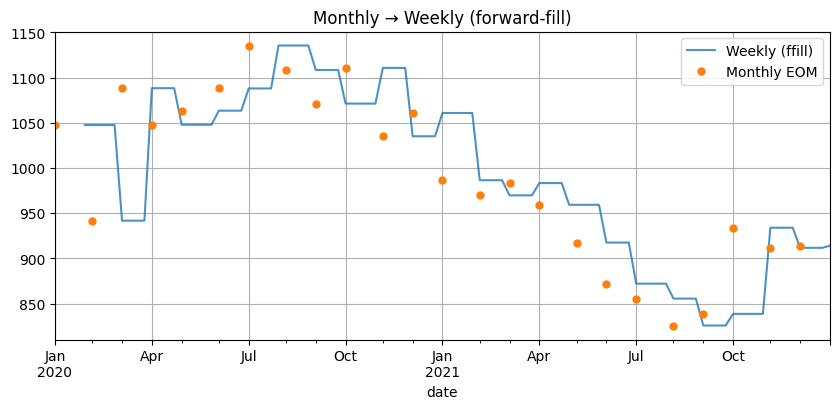

In [356]:
import matplotlib.pyplot as plt

ax = stocks_w_ffill.plot(figsize=(10,4), label="Weekly (ffill)", alpha=0.8)
price_m.plot(style="o", ax=ax, label="Monthly EOM", markersize=5)
plt.title("Monthly → Weekly (forward-fill)"); plt.grid(True); plt.legend(); plt.show()


Part 2- Upsampling & Interpolation with .resample()

Use interpolation to create weekly employment data
We’ll start from a monthly employment dataset (20 years), then upsample to weekly using interpolation. You’ll get a smooth, realistic weekly path suitable for dashboards and analysis.
📂 Dataset
We prepared a monthly dataset with:
date (month start)
labor_force_millions
employment_millions (derived from unemployment rate × labor force)
unemployment_rate (%)
Download it here:
📄 employment_monthly_20y.csv
🧠 Why interpolate?
Employment levels typically change gradually—a good fit for time interpolation.
Forward-fill produces a step function that can overstate abrupt changes on weekly charts.
If you want weekly data that reflects the monthly average more faithfully, a daily interpolation → weekly mean is a great pattern.

In [360]:
# 1) Load & index monthly data

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("employment_monthly_20y.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

# Ensure a proper monthly frequency (Month Start)
monthly = df.asfreq("MS")
monthly.info()
monthly.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2005-09-01 to 2025-08-01
Freq: MS
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   labor_force_millions  240 non-null    float64
 1   employment_millions   240 non-null    float64
 2   unemployment_rate     240 non-null    float64
dtypes: float64(3)
memory usage: 7.5 KB


,labor_force_millions,employment_millions,unemployment_rate
date,,,
2005-09-01,150.00,142.24,5.17
2005-10-01,150.23,142.14,5.39
2005-11-01,150.43,142.50,5.27
2005-12-01,150.55,142.99,5.02
2006-01-01,150.59,142.91,5.10


In [359]:
# 2) Create weekly employment with time interpolation
# Interpolate directly on a weekly grid anchored to Fridays (common for labor market displays).

weekly_interp = monthly["employment_millions"].resample("W-FRI").interpolate(method="time")
weekly_interp.head()

# method="time" respects actual timestamp distance (not just row counts).

date
2005-09-02   NaN
2005-09-09   NaN
2005-09-16   NaN
2005-09-23   NaN
2005-09-30   NaN
Freq: W-FRI, Name: employment_millions, dtype: float64

In [361]:
# 3) (Alternative) Daily interpolation → weekly mean
# If you interpret the monthly employment value as a monthly average, it’s sensible to first create a daily curve via interpolation, then average to weekly.

daily_curve = monthly["employment_millions"].resample("D").interpolate(method="time")
weekly_mean = daily_curve.resample("W-FRI").mean()
weekly_mean.head()

date
2005-09-02    142.238333
2005-09-09    142.223333
2005-09-16    142.200000
2005-09-23    142.176667
2005-09-30    142.153333
Freq: W-FRI, Name: employment_millions, dtype: float64

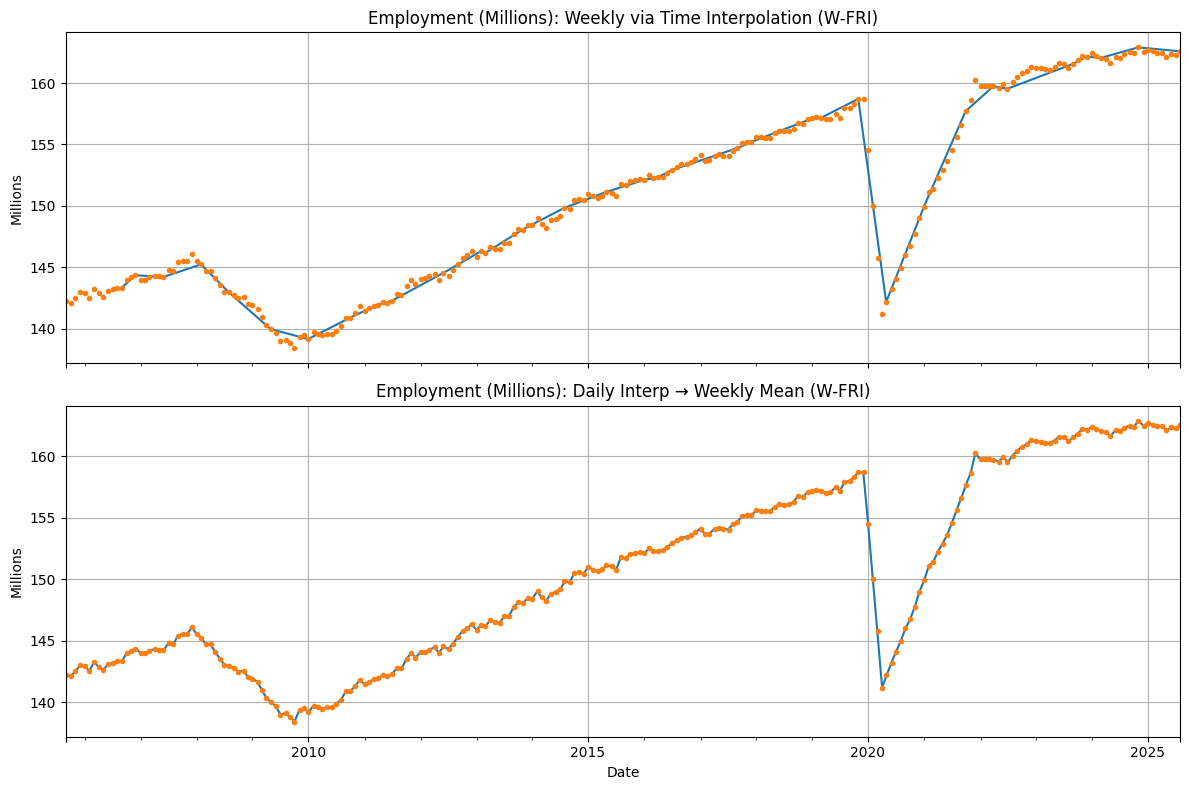

In [362]:
# 4) Plot & compare methods
# Overlay the monthly points to sanity-check both weekly series.

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# A) Weekly via time interpolation
weekly_interp.plot(ax=axes[0], title="Employment (Millions): Weekly via Time Interpolation (W-FRI)")
monthly["employment_millions"].plot(ax=axes[0], style="o", markersize=3)
axes[0].set_ylabel("Millions"); axes[0].grid(True)

# B) Daily interpolate → weekly mean
weekly_mean.plot(ax=axes[1], title="Employment (Millions): Daily Interp → Weekly Mean (W-FRI)")
monthly["employment_millions"].plot(ax=axes[1], style="o", markersize=3)
axes[1].set_ylabel("Millions"); axes[1].set_xlabel("Date"); axes[1].grid(True)

plt.tight_layout(); plt.show()

In [363]:
# 5) Sanity checks
# Missing values?

print("NaNs (weekly_interp):", weekly_interp.isna().sum())
print("NaNs (weekly_mean):", weekly_mean.isna().sum())

# Does weekly_mean preserve monthly averages reasonably? Compare the mean of weekly_mean within each month to the original monthly value:

monthly_from_weekly = weekly_mean.resample("MS").mean()
diff = (monthly_from_weekly - monthly["employment_millions"]).abs()
print("Median abs diff (millions):", float(diff.median()))
print("90th pct abs diff (millions):", float(diff.quantile(0.9)))

NaNs (weekly_interp): 52
NaNs (weekly_mean): 0
Median abs diff (millions): 0.10418836405528964
90th pct abs diff (millions): 0.3024665898617456


## Downsampling and Aggregation

- What downsampling is (higher → lower frequency) and when to use it.
- How to pick the right aggregation (mean, sum, last/first, median, custom).
- How to use resample() with labels, closed intervals, and anchored offsets.
- Finance-friendly tricks: OHLC, month-end vs month-start, monthly returns.
- Practical sanity checks so your numbers don’t lie.

1) Core idea: downsampling with resample()
Downsampling reduces the number of rows by grouping observations into time buckets and applying an aggregation.

- down = df.resample("<LOWER_FREQ>").<AGG>()
- Common lower frequencies:
- W (weekly), W-FRI (weeks ending on Fri)
- M (month-end), MS (month-start)
- Q (quarter-end), A (year-end)
- Business-aware: B (business day), BM, BMS, BQ, …

In [364]:
# 2) Daily → Monthly (finance example)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

goog = pd.read_csv("goog_simulated.csv", parse_dates=["date"], index_col="date")
price = goog["close_price"]

# A) Month-end "close" (common in markets)
m_close = price.resample("M").last()

# B) Monthly average price (less common for returns, fine for smoothing)
m_avg = price.resample("M").mean()

# C) OHLC in one shot (open/high/low/close)
m_ohlc = price.resample("M").ohlc()

print(m_close.head())
print(m_ohlc.head())

# 📌 When to use what

# last(): month-end close → best for monthly returns
# mean(): average level → descriptive, not for compounding returns
# ohlc(): dashboarding, candlesticks, volatility context


date
2020-01-31    1448.515094
2020-02-29    1297.440514
2020-03-31    1219.677896
2020-04-30    1283.067523
2020-05-31    1246.506836
Freq: ME, Name: close_price, dtype: float64
                   open         high          low        close
date                                                          
2020-01-31  1515.651425  1646.598966  1409.643036  1448.515094
2020-02-29  1407.963966  1407.963966  1269.606599  1297.440514
2020-03-31  1290.275951  1290.275951  1199.584240  1219.677896
2020-04-30  1253.371254  1363.483629  1252.192832  1283.067523
2020-05-31  1292.145254  1321.783182  1185.667371  1246.506836


/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/1283704673.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m_close = price.resample("M").last()
/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/1283704673.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m_avg = price.resample("M").mean()
/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/1283704673.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m_ohlc = price.resample("M").ohlc()


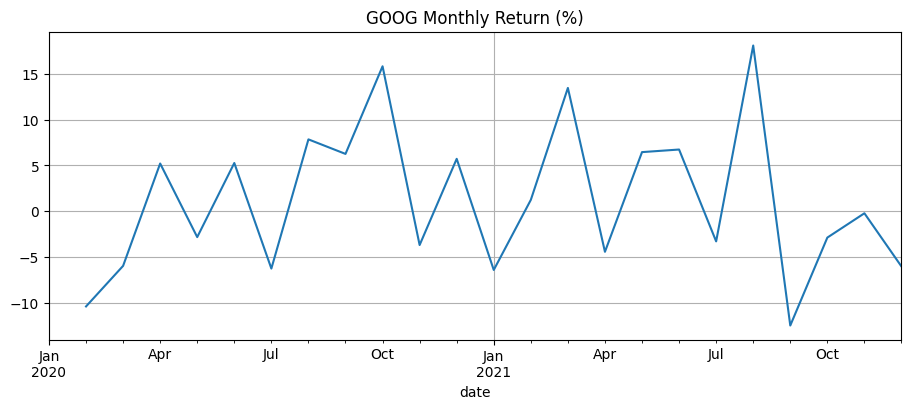

In [365]:
# 3) Monthly returns from daily prices
# Returns need endpoints. With month-end closes you can do:

m_ret = m_close.pct_change() * 100
m_ret.plot(title="GOOG Monthly Return (%)"); plt.grid(True); plt.show()


In [366]:
# Sanity check: daily → monthly, then back:
# Cumulative growth factors of daily returns per month ≈ 1 + monthly_return
daily_fac = (1 + price.pct_change()).resample("M").apply(lambda s: (s.dropna()+1).prod())
check = (daily_fac - (1 + m_ret/100)).abs().max()
print("Max diff in growth factor:", float(check))

Max diff in growth factor: 8942322.257542448


/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/864905805.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  daily_fac = (1 + price.pct_change()).resample("M").apply(lambda s: (s.dropna()+1).prod())


In [367]:
# 4) Daily → Weekly with labels & interval sides
# By default, weekly periods are right-labeled and left-closed (include the left endpoint). You can change that:

# Weekly mean, weeks ending Friday, intervals closed on the right
w_mean = price.resample("W-FRI", label="right", closed="right").mean()

# Weekly last (a "weekly close")
w_close = price.resample("W-FRI", label="right", closed="right").last()

# Why it matters: depending on closed/label, a boundary day (e.g., Fri) belongs to the current or next bucket. 
# Be consistent across series you compare.

In [368]:
# 5) Multiple columns & different aggregations
# Use a dict to apply different aggs per column. Example with (daily):

aq = pd.read_csv("air_quality_trends_simulated.csv", parse_dates=["date"], index_col="date")

monthly_aq = aq.resample("M").agg({
    "ozone": "mean",   # average daily ozone
    "pm25":  "max",    # worst monthly day
    "co":    "median"  # robust central tendency
})
monthly_aq.head()

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/620227537.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_aq = aq.resample("M").agg({


,ozone,pm25,co
date,,,
2023-01-31,58.545428,33.774998,0.814028
2023-02-28,53.289651,34.710350,0.893725
2023-03-31,50.632349,34.760337,0.849133
2023-04-30,56.824328,34.832024,0.923890
2023-05-31,57.523502,34.033840,0.941081


In [369]:
# 6) Business calendars & anchored offsets
# Financial data? Prefer business-aware anchors.
# Month-end on business calendar
bm_close = price.resample("BM").last()   # last business day of month

# Week anchored to Friday (already shown)
w_fri = price.resample("W-FRI").last()

# Quarter-end (calendar)
q_close = price.resample("Q").last()

# Choose the anchor that matches your reporting (e.g., W-SUN for retail, W-FRI for markets).

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2739634477.py:4: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  bm_close = price.resample("BM").last()   # last business day of month
/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2739634477.py:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_close = price.resample("Q").last()


In [370]:
# 7) Handling missing data before/after resampling
# Downsampling (via agg) usually ignores NaNs automatically, but sparse data can produce NaNs.
# Tips:

# Pre-fill short gaps *before* downsampling if appropriate
price_ff = price.asfreq("B").ffill(limit=2)      # fill ≥2-day gaps
m_close_ff = price_ff.resample("M").last()

# Or after downsampling, if you need a continuous series
m_close_filled = m_close.ffill()

# Be explicit: document any filling since it changes interpretation.

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/1973123963.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m_close_ff = price_ff.resample("M").last()


In [371]:
# 8) Custom aggregations & volatility
# You can pass callables or np.ptp (peak-to-peak) or lambda.
# Monthly volatility proxy: std of daily returns within the month
m_vol = price.pct_change().resample("M").std() * np.sqrt(21) * 100  # % monthly vol (annualize if you want)

# Or mix into one frame:
monthly_summary = pd.concat({
    "close": m_close,
    "ret_%": m_ret,
    "vol_%": m_vol
}, axis=1)
monthly_summary.head()

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/4228749561.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m_vol = price.pct_change().resample("M").std() * np.sqrt(21) * 100  # % monthly vol (annualize if you want)


,close,ret_%,vol_%
date,,,
2020-01-31,1448.515094,NaN,8.886921
2020-02-29,1297.440514,-10.429617,8.385018
2020-03-31,1219.677896,-5.993540,7.811784
2020-04-30,1283.067523,5.197243,9.815226
2020-05-31,1246.506836,-2.849475,6.877270


In [372]:
# 9) Grouping by calendar fields (alt to resample)
# For non-regular groupings (e.g., day of week):
dow_mean = price.groupby(price.index.day_name()).mean().sort_index()
print(dow_mean)

#Or use pd.Grouper(freq="M") within groupby when the index isn’t the date.

date
Friday       1612.681503
Monday       1616.693604
Thursday     1617.216967
Tuesday      1616.103922
Wednesday    1614.009378
Name: close_price, dtype: float64


## Seeing the Month Clearly: Mean, Median & Standard Deviation

What you’ll build
You’ll turn a daily time series into monthly insights by computing and visualizing the mean, median, and standard deviation for each month. You’ll practice resampling, handling missing data, and choosing the right chart to communicate stability vs. variability.

You’ll practice
- Resampling daily data to monthly with .resample("M")
- Computing multiple aggregations in one pass (mean, median, std)
- Plotting each statistic cleanly (separate charts to avoid scale confusion)
- Interpreting differences between mean vs median (outliers!) and what std is telling you
- Sanity checks (NaNs, min sample sizes, and “does this visualization match the question?”)

In [375]:
# Part A — Load & Inspect
# Goal: Ensure a time-aware index and check you’re actually at daily granularity.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("air_quality_trends_simulated.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

# Confirm structure
df.info()
df.head()
# Optional: ensure daily frequency gaps are visible (we won't fill yet)
df = df.asfreq("D")

# What to look for
# DatetimeIndex present? ✅
# Are columns numeric (not object)? ✅
# Any NaNs? Note them — std/median handle NaNs differently depending on method/kwargs.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2023-01-01 to 2023-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ozone   365 non-null    float64
 1   pm25    365 non-null    float64
 2   co      365 non-null    float64
dtypes: float64(3)
memory usage: 11.4 KB


In [376]:
# Part B — Compute Monthly Mean, Median, Std
# Goal: One tidy monthly table with all stats.

monthly_stats = df.resample("M").agg({
    "ozone": ["mean", "median", "std"],
    "pm25":  ["mean", "median", "std"],
    "co":    ["mean", "median", "std"]
})
monthly_stats.head()

# Tip: If your data has occasional missing days and you want a minimum sample size per month:

# require at least 20 daily values per month to compute stats
monthly_strict = df.resample("M").agg(
    ozone_mean  = ("ozone",  lambda s: s.mean()  if s.count() >= 20 else float("nan")),
    ozone_median= ("ozone",  lambda s: s.median()if s.count() >= 20 else float("nan")),
    ozone_std   = ("ozone",  lambda s: s.std()   if s.count() >= 20 else float("nan")),
    pm25_mean   = ("pm25",   lambda s: s.mean()  if s.count() >= 20 else float("nan")),
    pm25_median = ("pm25",   lambda s: s.median()if s.count() >= 20 else float("nan")),
    pm25_std    = ("pm25",   lambda s: s.std()   if s.count() >= 20 else float("nan")),
    co_mean     = ("co",     lambda s: s.mean()  if s.count() >= 20 else float("nan")),
    co_median   = ("co",     lambda s: s.median()if s.count() >= 20 else float("nan")),
    co_std      = ("co",     lambda s: s.std()   if s.count() >= 20 else float("nan")),
)


/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2007737127.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_stats = df.resample("M").agg({
/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2007737127.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_strict = df.resample("M").agg(


/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2239843391.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean = df.resample("M").mean(numeric_only=True)


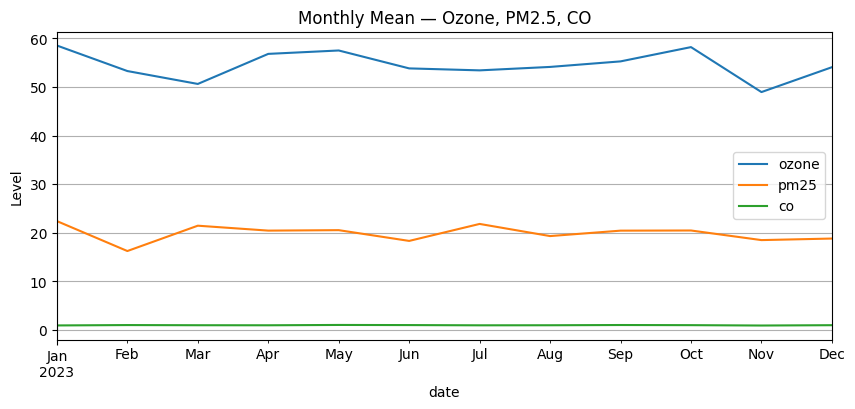

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2239843391.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_median = df.resample("M").median(numeric_only=True)


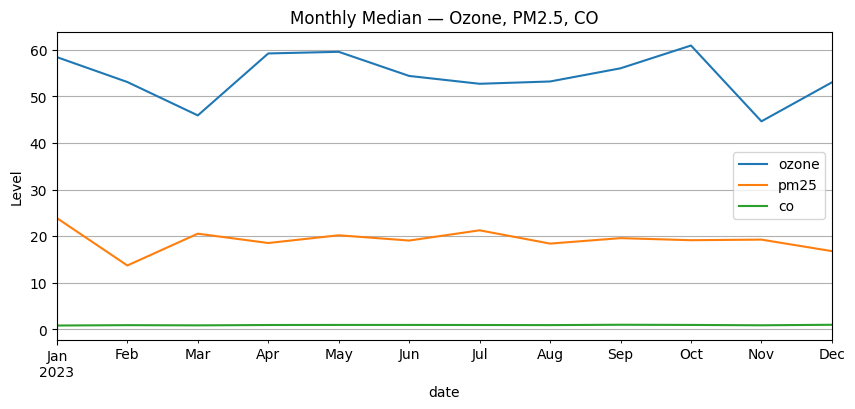

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2239843391.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_std = df.resample("M").std(numeric_only=True)


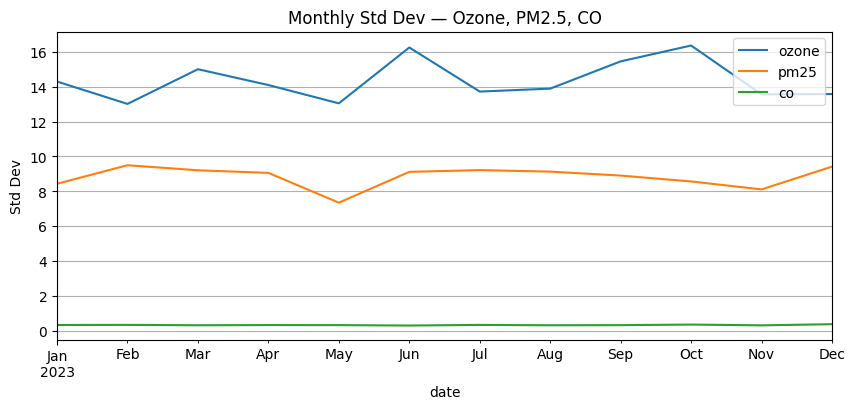

In [377]:
# Part C — Visualize the Three Statistics
# Goal: Three clean charts (no subplots jammed together). Keep scales honest.

# Monthly mean
monthly_mean = df.resample("M").mean(numeric_only=True)
monthly_mean.plot(title="Monthly Mean — Ozone, PM2.5, CO", figsize=(10,4))
plt.ylabel("Level"); plt.grid(True); plt.show()

# Monthly median
monthly_median = df.resample("M").median(numeric_only=True)
monthly_median.plot(title="Monthly Median — Ozone, PM2.5, CO", figsize=(10,4))
plt.ylabel("Level"); plt.grid(True); plt.show()

# Monthly standard deviation
monthly_std = df.resample("M").std(numeric_only=True)
monthly_std.plot(title="Monthly Std Dev — Ozone, PM2.5, CO", figsize=(10,4))
plt.ylabel("Std Dev"); plt.grid(True); plt.show()

Reading the charts
Mean vs Median: If mean ≫ median in a month, you likely had high spikes (positive skew/outliers). If median ≫ mean, low dips pulled the mean down.
Std Dev: High standard deviation months = volatile month (bigger day-to-day swings), even if the mean looks “normal

In [379]:
# Part D — Annotate Extremes & Compare Metrics
# Goal: Make insights obvious for a reader.
mm = monthly_mean.copy()
ms = monthly_std.copy()

# Mark the month with the highest PM2.5 mean and highest PM2.5 std
pm25_max_mean_month = mm["pm25"].idxmax()
pm25_max_std_month  = ms["pm25"].idxmax()
print("Highest PM2.5 mean month:", pm25_max_mean_month.date())
print("Highest PM2.5 std month:",  pm25_max_std_month.date())


Highest PM2.5 mean month: 2023-01-31
Highest PM2.5 std month: 2023-02-28


In [380]:
# Part E  — Sanity Checks (don’t skip)
# Sample size check: df.resample("M").count() to ensure each month has enough days.
# NaN awareness: If you see NaNs in monthly stats, do you fill daily data before resampling or drop those months? Document the choice.
# Unit/scale consistency: Don’t plot ppm and μg/m³ on the same y-axis unless you label clearly.

## Rolling Window Functions with Pandas

- Explain what rolling, expanding, and exponentially weighted windows are and when to use each.
- Use .rolling() with row-based windows (e.g., window=7) and time-based windows (e.g., window="14D"), including min_periods and center.
- Compute and plot moving averages, rolling volatility, rolling correlations, and custom rolling metrics.
- Avoid common pitfalls (NaNs at the start, window alignment, data leakage in modeling).

Rolling windows turn noisy time series into interpretable signals.
Society & environment: 7-day averages of air quality or COVID cases smooth weekend effects and guide policy.
Business: rolling sales trends and conversion rates expose momentum or seasonality.
Finance: rolling volatility, beta, and correlations support portfolio risk management.
People: moving averages in wearables (steps, heart rate) reduce noise to show real behavior change.

In [381]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Air quality (daily)
aq = pd.read_csv("air_quality_trends_simulated.csv", parse_dates=["date"], index_col="date").asfreq("D")

# GOOG prices (business-daily)
goog = pd.read_csv("goog_simulated.csv", parse_dates=["date"], index_col="date")
goog = goog.asfreq("B")  # ensure business-day frequency
price = goog["close_price"]

# Multi-asset (business-daily)
assets = pd.read_csv("assets_simulated.csv", parse_dates=["date"], index_col="date").asfreq("B")

plt.rcParams["figure.figsize"] = (10, 4)

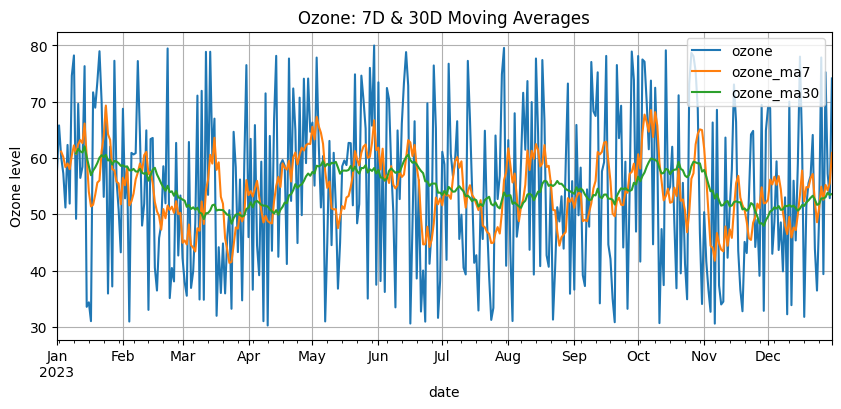

In [382]:
# ) Rolling basics — smoothing with moving averages (air quality)
# Concept: A rolling/“moving” window computes a statistic over the last N observations (row-based) or last N units of time (time-based).

# Row-based windows (last N rows)
aq["ozone_ma7"]  = aq["ozone"].rolling(window=7, min_periods=3).mean()
aq["ozone_ma30"] = aq["ozone"].rolling(window=30, min_periods=10).mean()

ax = aq[["ozone", "ozone_ma7", "ozone_ma30"]].plot(title="Ozone: 7D & 30D Moving Averages")
ax.set_ylabel("Ozone level"); ax.grid(True); plt.show()

# Why min_periods? Early windows don’t have enough rows; min_periods lets you start producing values sooner (with a warning to interpret carefully).

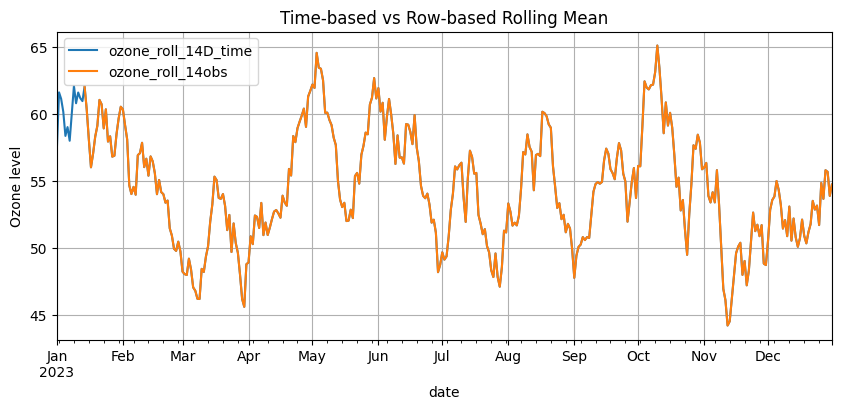

In [384]:
# 2) Time-based windows vs row-based windows
# Time-based: last 14 calendar days (uses timestamps, robust to gaps)
aq["ozone_roll_14D_time"] = aq["ozone"].rolling("14D").mean()

# Row-based: last 14 observations (ignores actual time span)
aq["ozone_roll_14obs"] = aq["ozone"].rolling(14).mean()

aq[["ozone_roll_14D_time","ozone_roll_14obs"]].plot(title="Time-based vs Row-based Rolling Mean")
plt.ylabel("Ozone level"); plt.grid(True); plt.show()

# Use time-based windows when your index has real-world spacing (irregular sampling, missing dates). 
# Use row-based windows when every row is equally spaced and complete.


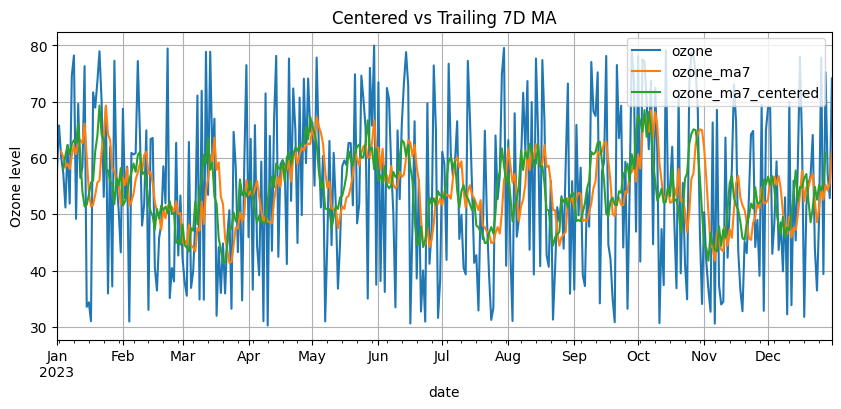

In [385]:
# 3) Centered windows (better alignment for visualization)

aq["ozone_ma7_centered"] = aq["ozone"].rolling(7, center=True).mean()
aq[["ozone","ozone_ma7","ozone_ma7_centered"]].plot(title="Centered vs Trailing 7D MA")
plt.ylabel("Ozone level"); plt.grid(True); plt.show()

# center=True aligns the window’s statistic at the middle of the window (nice for chart alignment, not for forecasting because it “peeks” into the future).


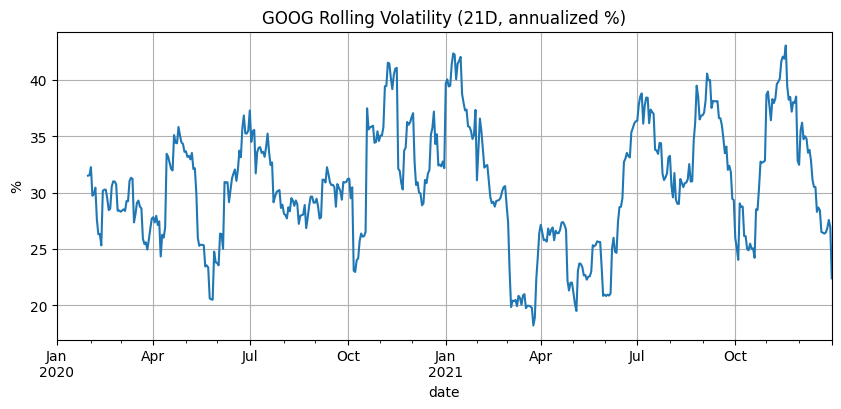

In [386]:
# 4) Rolling returns & volatility (finance)
# Daily returns
ret = price.pct_change()

# 21 trading-day rolling volatility (approx. 1 month)
roll_vol_21 = ret.rolling(21).std() * np.sqrt(252) * 100  # annualized %

fig, ax = plt.subplots()
roll_vol_21.plot(ax=ax, title="GOOG Rolling Volatility (21D, annualized %)")
ax.set_ylabel("%"); ax.grid(True); plt.show()

# Volatility is the rolling standard deviation of returns; annualize with √252 for business days.


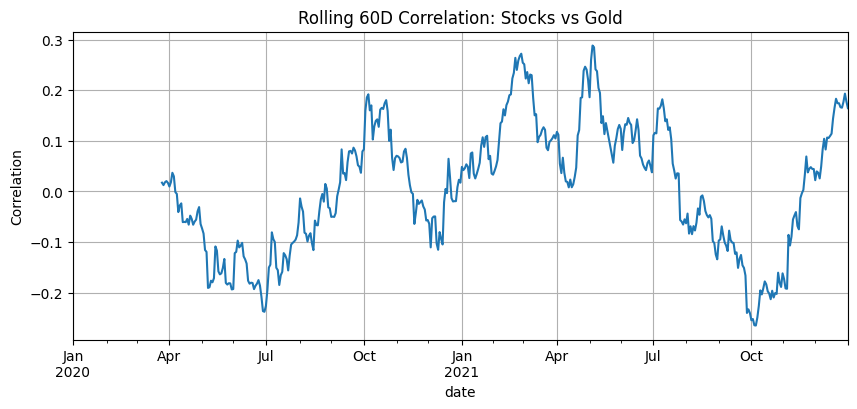

In [387]:
# 5) Rolling correlation (cross-asset relationships)
rets = assets.pct_change()
roll_corr_60 = rets["stocks"].rolling(60).corr(rets["gold"])

roll_corr_60.plot(title="Rolling 60D Correlation: Stocks vs Gold")
plt.ylabel("Correlation"); plt.grid(True); plt.show()

# Rolling correlations reveal regime shifts (e.g., crisis periods when assets co-move).


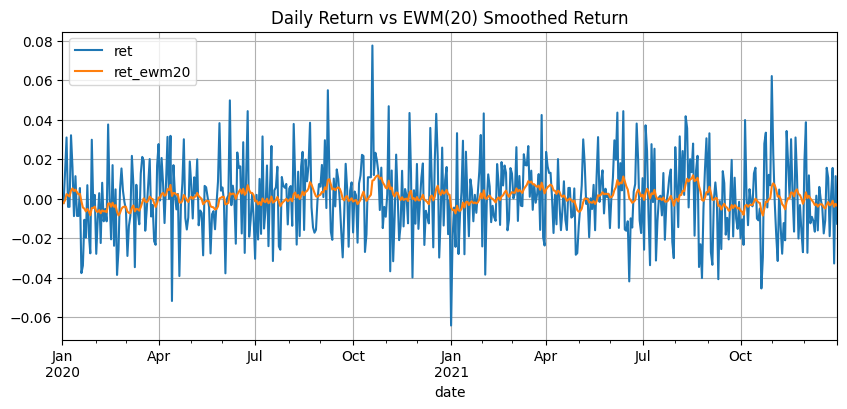

In [388]:
# 6) Expanding vs exponentially weighted windows
# Expanding = from start to current point (growing window)
aq["ozone_expanding_mean"] = aq["ozone"].expanding(min_periods=10).mean()

# EWM = recent observations get more weight (fades the past)
goog["ret"] = goog["close_price"].pct_change()
goog["ret_ewm20"] = goog["ret"].ewm(span=20, adjust=False).mean()

fig, ax = plt.subplots()
goog[["ret","ret_ewm20"]].plot(ax=ax, title="Daily Return vs EWM(20) Smoothed Return")
ax.grid(True); plt.show()

# Use expanding for cumulative KPIs; use EWM when you want faster response to new data.

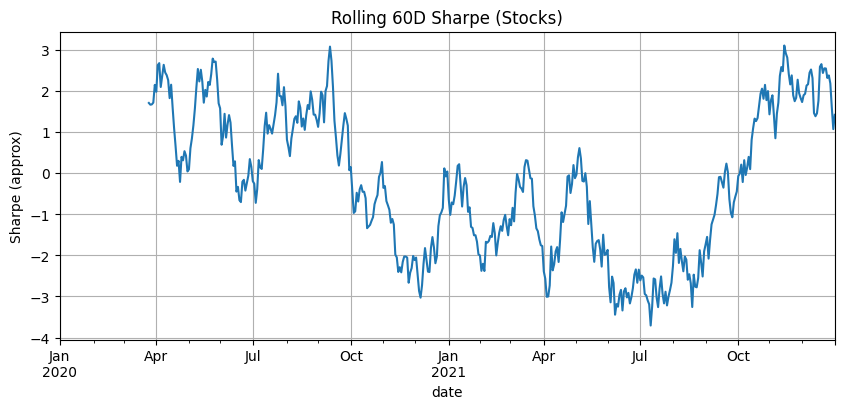

In [389]:
# 7) Custom rolling metrics (e.g., rolling Sharpe)
# Rolling Sharpe (mean/std) * sqrt(252) — simple illustration
roll_mean = rets["stocks"].rolling(60).mean()
roll_std  = rets["stocks"].rolling(60).std()
roll_sharpe_60 = (roll_mean / roll_std) * np.sqrt(252)

roll_sharpe_60.plot(title="Rolling 60D Sharpe (Stocks)")
plt.ylabel("Sharpe (approx)"); plt.grid(True); plt.show()

# .rolling().apply(func) also lets you plug in any custom function (just watch performance).


⚠️ Pitfalls & Best Practices
- NaNs at the start: expected; control with min_periods and explain in your charts.
- Alignment: center=True is for visualization, not for causal modeling.
- Time vs rows: use time-based windows if your timeline has gaps/irregularities.
- Data leakage: trailing windows only when creating model features.
- Scale: rolling stats may require axis labels/units (e.g., “volatility (%)”).

## Robust Smoothing & Variability: Rolling Median & Rolling Standard Deviation

- Explain when to use rolling median (robust smoothing) vs rolling mean (sensitive smoothing).
Compute rolling standard deviation to measure local variability and risk.
- Choose between row-based (e.g., window=14) and time-based windows (e.g., window="14D"), and set min_periods appropriately.
- Detect anomalies using rolling baselines (mean/median) and variability thresholds (std / MAD).
- Use expanding median/std for cumulative context.

💡 Why it matters
Society & environment: Rolling medians stabilize noisy sensor series (air quality, temperatures) and reduce outlier impact (faulty readings).
Business: Rolling std highlights volatile sales periods and campaign effects; rolling medians dampen promo spikes for clearer trend.
Finance: Rolling std is volatility; rolling medians of returns provide a robust signal during turbulence.
People: Health and wearables (HRV, steps) benefit from robust smoothing to avoid overreacting to sporadic spikes.

In [390]:

# 🛠️ Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 4)

def load_or_simulate_air_quality(path="air_quality_trends_simulated.csv"):
    p = Path(path)
    if p.exists():
        df = pd.read_csv(p, parse_dates=["date"], index_col="date")
    else:
        # Fallback: simulate daily data for 2023
        rng = pd.date_range("2023-01-01", "2023-12-31", freq="D")
        rs = np.random.RandomState(0)
        df = pd.DataFrame({
            "ozone": rs.uniform(30, 80, size=len(rng)),
            "pm25":  rs.uniform(5, 35, size=len(rng)),
            "co":    rs.uniform(0.4, 1.5, size=len(rng))
        }, index=rng)
    return df.asfreq("D")

def load_or_simulate_goog(path="goog_simulated.csv"):
    p = Path(path)
    if p.exists():
        df = pd.read_csv(p, parse_dates=["date"], index_col="date")
    else:
        # Fallback: simulate GBM-like close prices on business days (2020–2021)
        dates = pd.date_range("2020-01-01", "2021-12-31", freq="B")
        n, dt = len(dates), 1/252
        mu, sigma, s0 = 0.12, 0.22, 100.0
        rs = np.random.RandomState(42)
        logret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*rs.normal(size=n)
        price = s0 * np.exp(np.cumsum(logret))
        df = pd.DataFrame({"close_price": price}, index=dates)
    return df.asfreq("B")


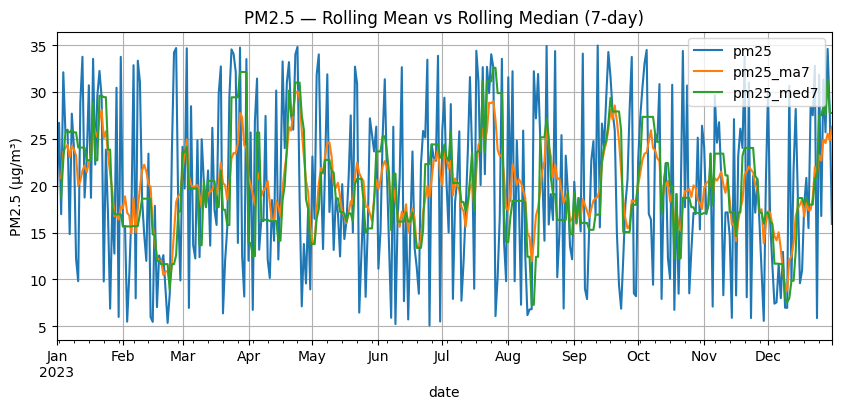

In [391]:
# 1) Rolling Median vs Rolling Mean (robust vs sensitive)
# When to use which?
# Rolling median is robust to outliers (spikes).
# Rolling mean is sensitive: it will move toward spikes/dips.

aq = load_or_simulate_air_quality()

# Choose a pollutant with occasional spikes (e.g., PM2.5)
aq["pm25_ma7"]   = aq["pm25"].rolling(window=7,  min_periods=3).mean()
aq["pm25_med7"]  = aq["pm25"].rolling(window=7,  min_periods=3).median()

ax = aq[["pm25", "pm25_ma7", "pm25_med7"]].plot(title="PM2.5 — Rolling Mean vs Rolling Median (7-day)")
ax.set_ylabel("PM2.5 (μg/m³)"); ax.grid(True); plt.show()

# Notice how the median line resists single-day spikes better than the mean.


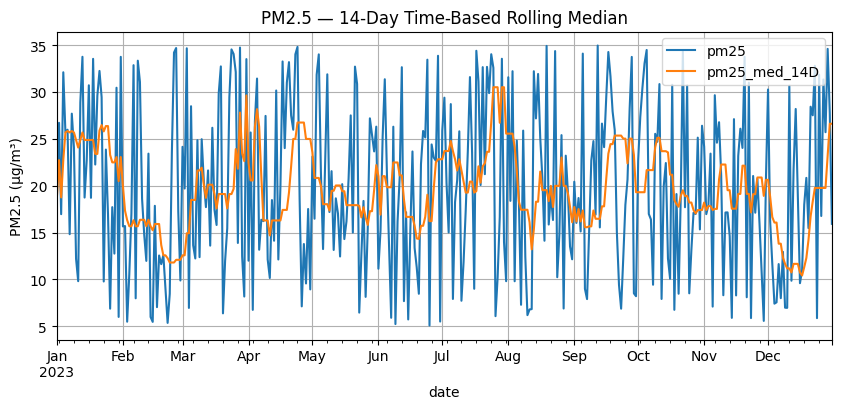

In [392]:
# Time-based window (handles gaps):
aq["pm25_med_14D"] = aq["pm25"].rolling("14D").median()
aq[["pm25", "pm25_med_14D"]].plot(title="PM2.5 — 14-Day Time-Based Rolling Median")
plt.ylabel("PM2.5 (μg/m³)"); plt.grid(True); plt.show()

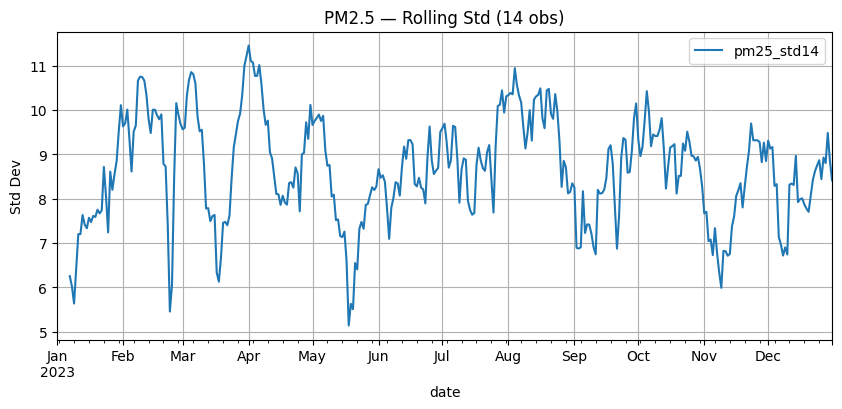

In [393]:
# 2) Rolling Standard Deviation (local variability / risk)
# Local variability over the last 14 observations
aq["pm25_std14"] = aq["pm25"].rolling(14, min_periods=7).std()

ax = aq[["pm25_std14"]].plot(title="PM2.5 — Rolling Std (14 obs)")
ax.set_ylabel("Std Dev"); ax.grid(True); plt.show()


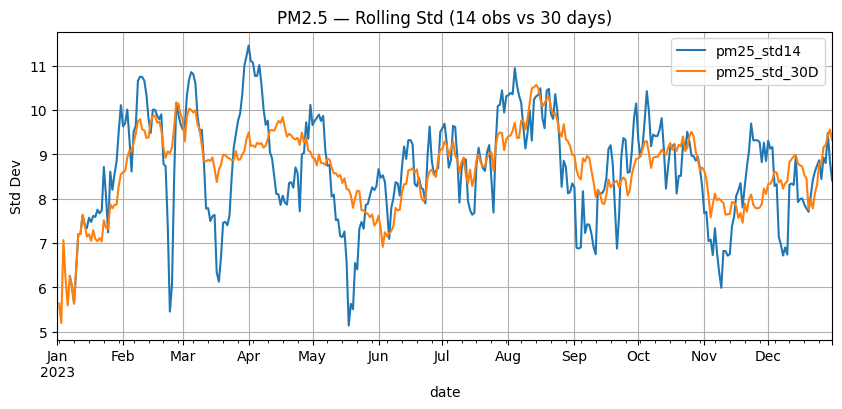

In [394]:
# Time-based std (e.g., 30 days):
aq["pm25_std_30D"] = aq["pm25"].rolling("30D").std()
aq[["pm25_std14", "pm25_std_30D"]].plot(title="PM2.5 — Rolling Std (14 obs vs 30 days)")
plt.ylabel("Std Dev"); plt.grid(True); plt.show()

# rolling().std() uses sample std (ddof=1) by default. That’s fine for most analytics.

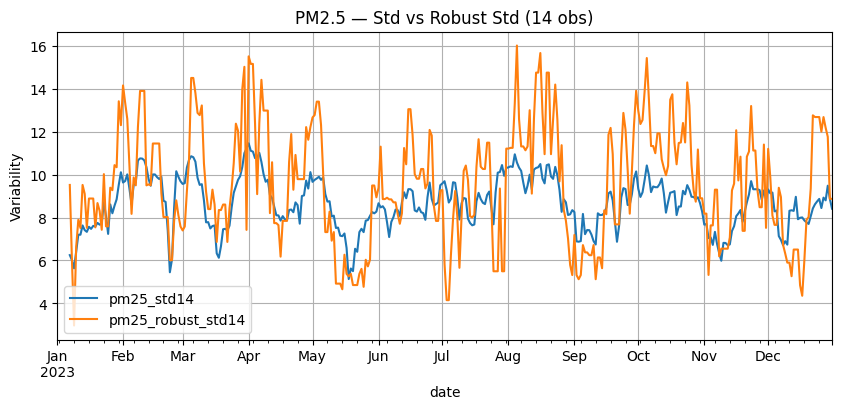

In [395]:
# 3) Robust Variability: Rolling MAD → “robust std”
# The Median Absolute Deviation (MAD) is robust to outliers. Convert to a “sigma-like” scale with MAD × 1.4826.
def rolling_mad(s):
    med = np.median(s)
    return np.median(np.abs(s - med))

aq["pm25_mad14"] = aq["pm25"].rolling(14, min_periods=7).apply(rolling_mad, raw=True)
aq["pm25_robust_std14"] = aq["pm25_mad14"] * 1.4826

aq[["pm25_std14", "pm25_robust_std14"]].plot(title="PM2.5 — Std vs Robust Std (14 obs)")
plt.ylabel("Variability"); plt.grid(True); plt.show()

# Compare standard vs robust variability: robust stays stable when isolated spikes occur.

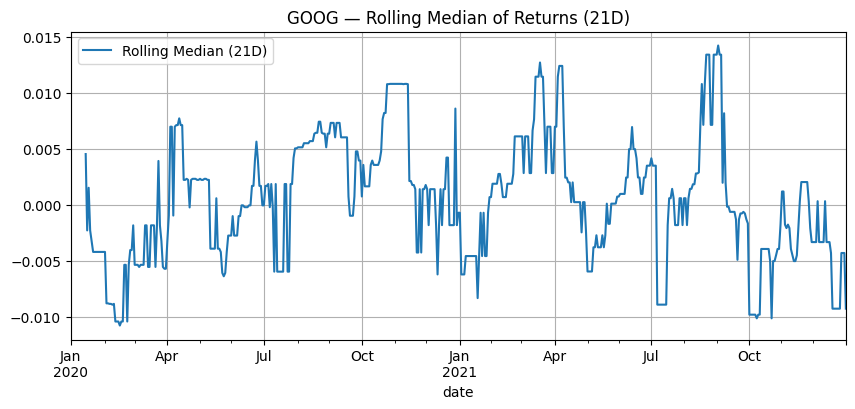

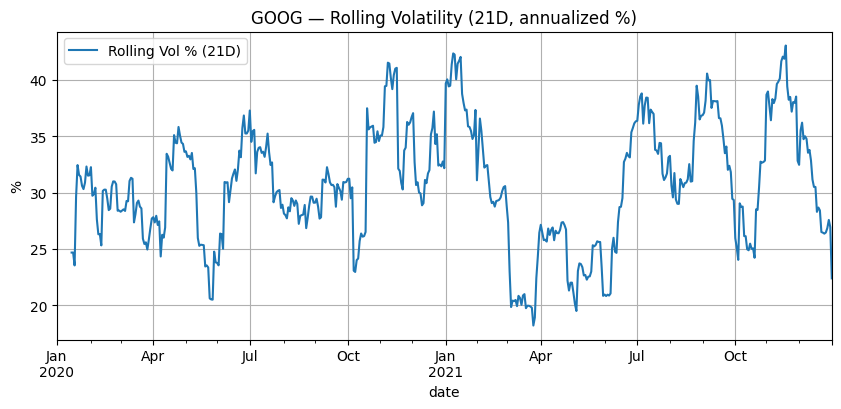

In [396]:
# 4) Finance: Rolling Median & Rolling Volatility on Returns
goog = load_or_simulate_goog()
ret = goog["close_price"].pct_change()

# Rolling median of returns (robust location)
roll_med_21 = ret.rolling(21, min_periods=10).median()

# Rolling std (volatility), annualized
roll_vol_21 = ret.rolling(21, min_periods=10).std() * np.sqrt(252) * 100

fig, ax = plt.subplots()
pd.concat({"Rolling Median (21D)": roll_med_21}, axis=1).plot(ax=ax, title="GOOG — Rolling Median of Returns (21D)")
ax.grid(True); plt.show()

fig, ax = plt.subplots()
pd.concat({"Rolling Vol % (21D)": roll_vol_21}, axis=1).plot(ax=ax, title="GOOG — Rolling Volatility (21D, annualized %)")
ax.set_ylabel("%"); ax.grid(True); plt.show()

In [397]:
# 5) Anomaly Detection with Rolling Baselines
# Mean-based rule (sensitive): flag |value − rolling mean| > k×rolling std
# Median-based rule (robust): flag |value − rolling median| > k×(MAD×1.4826)
w = 14
baseline = aq["pm25"].rolling(w, min_periods=7).mean()
sigma    = aq["pm25"].rolling(w, min_periods=7).std()
k = 2.5

anomaly_mean = (aq["pm25"] - baseline).abs() > (k * sigma)

# Robust version
baseline_med = aq["pm25"].rolling(w, min_periods=7).median()
mad = aq["pm25"].rolling(w, min_periods=7).apply(rolling_mad, raw=True)
robust_sigma = mad * 1.4826
anomaly_robust = (aq["pm25"] - baseline_med).abs() > (k * robust_sigma)

print("Mean-based anomalies:", int(anomaly_mean.sum()))
print("Robust-based anomalies:", int(anomaly_robust.sum()))

# Robust rules usually flag fewer, more credible anomalies when the data contain spikes.
# Mean-based anomalies: 0
# Robust-based anomalies: 10

Mean-based anomalies: 0
Robust-based anomalies: 10


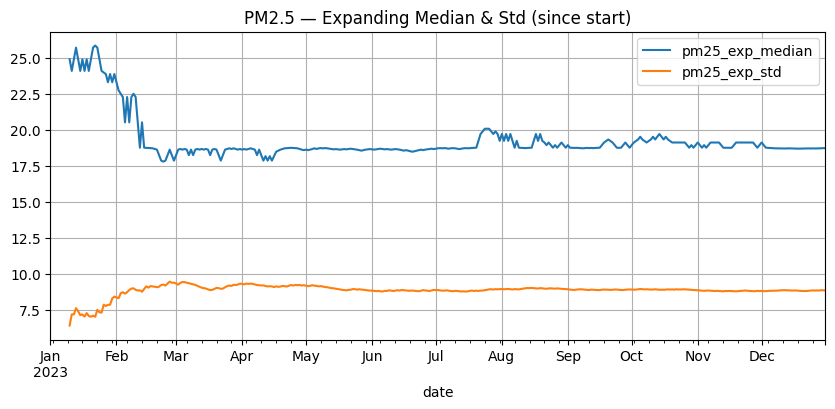

In [398]:
# 6) Expanding Metrics (cumulative context)
# Expanding median and std from start to current date
aq["pm25_exp_median"] = aq["pm25"].expanding(min_periods=10).median()
aq["pm25_exp_std"]    = aq["pm25"].expanding(min_periods=10).std()

aq[["pm25_exp_median", "pm25_exp_std"]].plot(title="PM2.5 — Expanding Median & Std (since start)")
plt.grid(True); plt.show()


# Expanding stats answer: “What’s the typical level/variability up to now?”

✅ Pitfalls & Best Practices
- NaNs at the start are normal; use min_periods and label plots accordingly.
- Window choice: shorter windows respond faster but are noisier; longer windows are smoother but lag.
- Time vs row windows: prefer time-based when data have gaps or irregular sampling.
- Robust vs sensitive: try median/MAD when outliers are frequent.
- Don’t use centered windows for modeling (it leaks future info).


## Relationships Between Time Series: Correlation

- Understand what correlation measures (and what it doesn’t measure).
- Compute pairwise correlation (Pearson & Spearman) between time series.
- Track changing relationships with rolling correlation.
- Explore lead–lag patterns with simple cross-correlation (via shifts).
- Interpret outputs cautiously (levels vs returns, alignment, outliers, etc.).

In [400]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)

# 1) Load the dataset (same directory as notebook)
df = pd.read_csv("assets_simulated.csv", parse_dates=["date"], index_col="date")

# 2) Use returns (pct_change) to avoid spurious correlation from shared trends in price levels
rets = df.pct_change().dropna()
rets.head()

# Why returns?
# Trending price levels often look correlated even when they’re not causally related. 
# Returns (or first differences) remove the common trend and make correlation more meaningful.

,stocks,bonds,gold,oil
date,,,,
2020-01-02,0.011629,-0.001297,-0.000511,0.003546
2020-01-03,0.003468,0.001415,-0.004537,0.012851
2020-01-06,-0.016686,0.002009,0.002568,0.022405
2020-01-07,-0.006288,-0.003444,-0.009352,-0.008212
2020-01-08,0.019160,0.002280,0.002474,-0.001518


In [402]:
# 1) Pairwise Correlation Matrices
# Pearson correlation (linear, sensitive to outliers)

corr_pearson = rets.corr()
corr_pearson

# How to read:
# Range: −1 (perfect opposite) to +1 (perfect together); 0 ≈ no linear relationship.
# Symmetric; diagonal is 1.0.

,stocks,bonds,gold,oil
stocks,1.000000,-0.033459,0.004465,-0.006379
bonds,-0.033459,1.000000,0.065448,-0.006140
gold,0.004465,0.065448,1.000000,-0.044776
oil,-0.006379,-0.006140,-0.044776,1.000000


In [403]:
# Spearman correlation (rank-based, more robust to outliers / nonlinear monotonic)
corr_spearman = rets.corr(method="spearman")
corr_spearman

,stocks,bonds,gold,oil
stocks,1.000000,-0.042516,-0.012078,-0.022387
bonds,-0.042516,1.000000,0.069578,-0.013857
gold,-0.012078,0.069578,1.000000,-0.046545
oil,-0.022387,-0.013857,-0.046545,1.000000


Interpretation tip:
- If Pearson and Spearman differ materially, the relationship may be nonlinear or outlier-prone.

(Optional) Save as CSV for later reporting:
- corr_pearson.to_csv("corr_pearson_returns.csv")
- corr_spearman.to_csv("corr_spearman_returns.csv")

In [404]:
# 2) Quick Scan vs a “Benchmark” with corrwith
# Correlation of every asset with 'stocks' (as a simple benchmark)
corr_with_stocks = rets.drop(columns="stocks").corrwith(rets["stocks"]).sort_values(ascending=False)
corr_with_stocks

gold     0.004465
oil     -0.006379
bonds   -0.033459
dtype: float64

Interpretation:
A fast ranking of co-movement with the stock market. Positive = tends to rise/fall with stocks; negative = tends to move opposite.

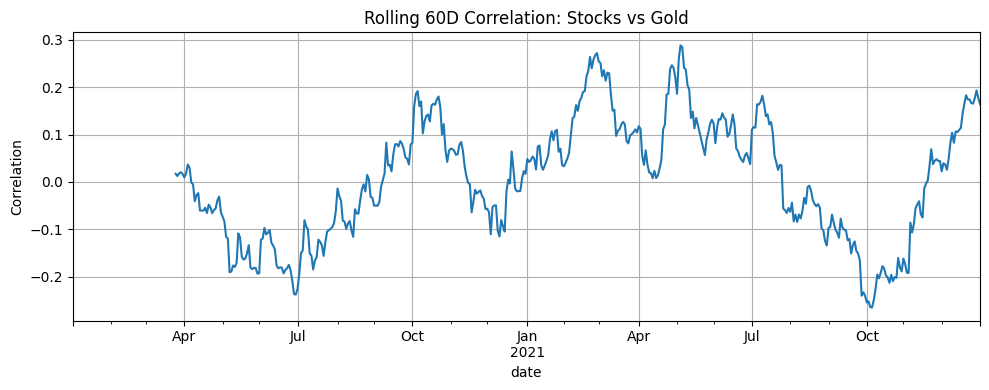

In [405]:
# 3) Rolling Correlation (Relationships Change Over Time)
# 60-trading-day rolling correlation between Stocks and Gold
roll_corr_60 = rets["stocks"].rolling(60).corr(rets["gold"])

ax = roll_corr_60.plot(title="Rolling 60D Correlation: Stocks vs Gold")
ax.set_ylabel("Correlation"); ax.grid(True)
plt.tight_layout()
#plt.savefig("rolling_corr_stocks_gold_60d.png", dpi=200, bbox_inches="tight")
plt.show()

How to interpret:
Higher values ⇒ stronger co-movement (same direction).
Lower/negative values ⇒ diversification potential.
Window trade-off: shorter window (e.g., 20D) is reactive/noisy; longer (e.g., 120D) is smoother/lagged.


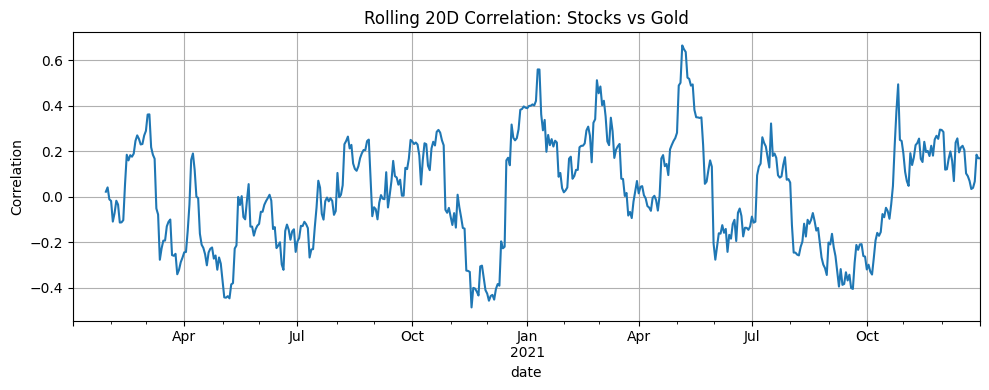

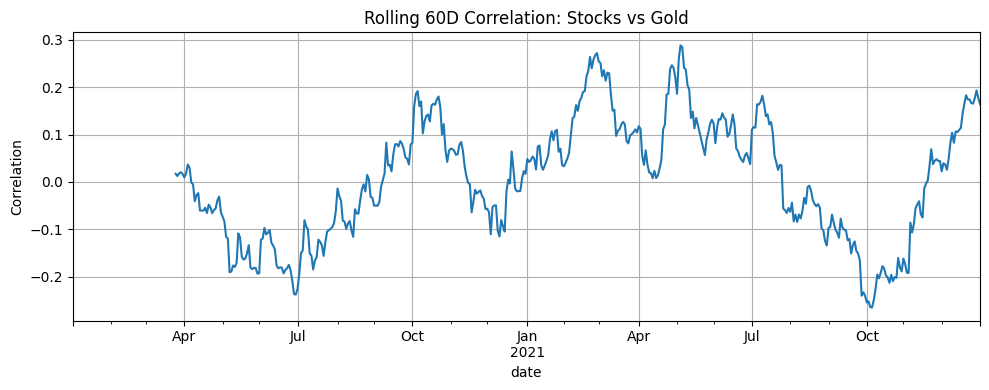

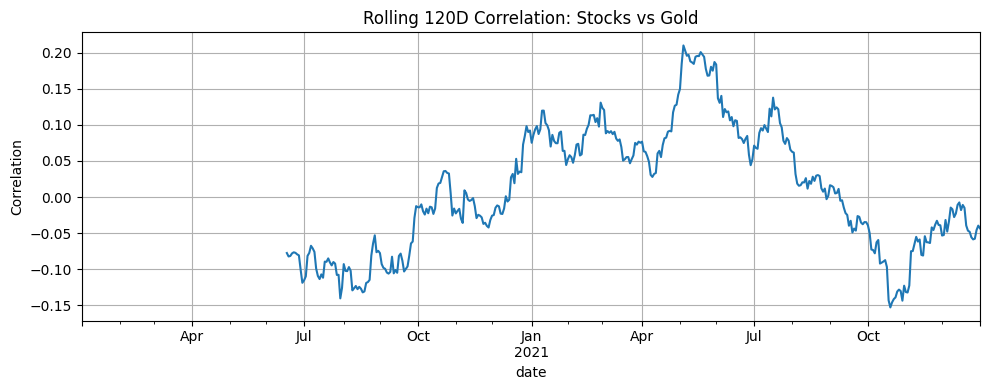

In [406]:
# (Try multiple windows to see stability vs reactivity.)
for w in [20, 60, 120]:
    rc = rets["stocks"].rolling(w).corr(rets["gold"])
    ax = rc.plot(title=f"Rolling {w}D Correlation: Stocks vs Gold")
    ax.set_ylabel("Correlation"); ax.grid(True)
    plt.tight_layout()
    plt.savefig(f"rolling_corr_stocks_gold_{w}d.png", dpi=200, bbox_inches="tight")
    plt.show()

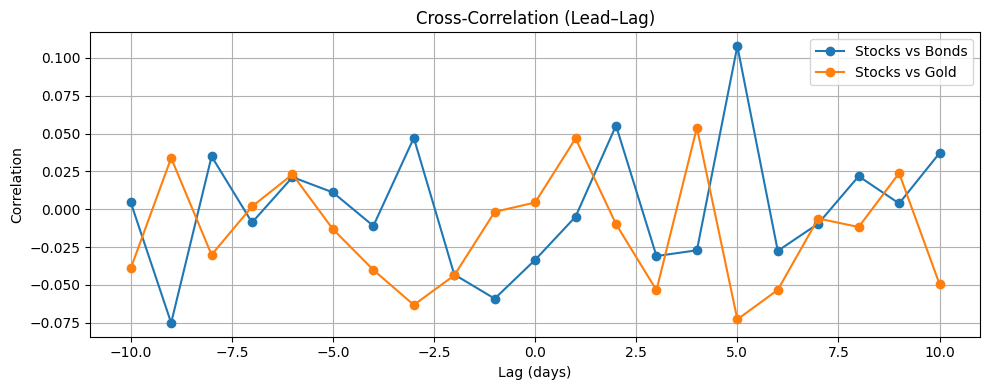

(-10    0.004566
 -9    -0.075093
 -8     0.034929
 -7    -0.008758
 -6     0.021221
 -5     0.011118
 -4    -0.011030
 -3     0.047128
 -2    -0.043131
 -1    -0.059080
  0    -0.033459
  1    -0.004909
  2     0.055301
  3    -0.030916
  4    -0.027124
  5     0.107750
  6    -0.027518
  7    -0.009503
  8     0.021822
  9     0.003820
  10    0.037122
 dtype: float64,
 -10   -0.039147
 -9     0.033852
 -8    -0.030110
 -7     0.001819
 -6     0.023020
 -5    -0.013187
 -4    -0.040117
 -3    -0.063238
 -2    -0.043729
 -1    -0.001737
  0     0.004465
  1     0.046787
  2    -0.009827
  3    -0.053478
  4     0.053911
  5    -0.072795
  6    -0.053286
  7    -0.006123
  8    -0.011733
  9     0.023847
  10   -0.049521
 dtype: float64)

In [407]:
# 4) Lead–Lag Exploration (Cross-Correlation via Shifts)
# “Does one series tend to move before the other?” We can scan correlations at different lags:

def xcorr(a, b, max_lag=10):
    """
    Cross-correlation by simple shifting.
    Returns a Series indexed by lag:
      negative lag -> 'a' leads 'b'
      positive lag -> 'b' leads 'a'
    """
    out = {}
    for L in range(-max_lag, max_lag + 1):
        if L < 0:   # a leads b
            out[L] = a.shift(-L).corr(b)
        else:       # b leads a
            out[L] = a.corr(b.shift(L))
    return pd.Series(out)

xc_sb = xcorr(rets["stocks"], rets["bonds"], max_lag=10)
xc_sg = xcorr(rets["stocks"], rets["gold"],  max_lag=10)

ax = xc_sb.plot(marker="o", label="Stocks vs Bonds")
xc_sg.plot(ax=ax, marker="o", label="Stocks vs Gold")
ax.set_title("Cross-Correlation (Lead–Lag)")
ax.set_xlabel("Lag (days)"); ax.set_ylabel("Correlation")
ax.grid(True); ax.legend()
plt.tight_layout()
#plt.savefig("cross_correlation_lead_lag.png", dpi=200, bbox_inches="tight")
plt.show()

xc_sb, xc_sg

How to interpret the lags:
Lag < 0: the first series (here, stocks) leads the second by |lag| days.
Lag > 0: the second series leads the first.
Look for the peak correlation and its lag. Treat it as a hint, not proof of causality.

In [411]:
# 5) Correlation in Subperiods (Before/After an Event)
split = "2021-01-01"
corr_pre  = rets.loc[:split].corr()
corr_post = rets.loc[split:].corr()

corr_pre, corr_post

(          stocks     bonds      gold       oil
 stocks  1.000000 -0.063933 -0.017242  0.048241
 bonds  -0.063933  1.000000  0.037762 -0.072970
 gold   -0.017242  0.037762  1.000000 -0.066663
 oil     0.048241 -0.072970 -0.066663  1.000000,
           stocks     bonds      gold       oil
 stocks  1.000000 -0.003697  0.030736 -0.061453
 bonds  -0.003697  1.000000  0.104789  0.084988
 gold    0.030736  0.104789  1.000000 -0.024954
 oil    -0.061453  0.084988 -0.024954  1.000000)

Interpretation:
Check whether a pair (e.g., stocks–gold) got more or less correlated after the split. This informs diversification and regime changes.

### Interpretation Cheatsheet
- Use returns (or diffs), not levels, to avoid misleading “trend” correlation.
- Pearson = linear (sensitive to outliers); Spearman = rank/monotonic (more robust).
- Rolling correlation shows regime shifts—choose window based on your need for responsiveness vs stability.
- Lead–lag via shifting suggests precedence but doesn’t prove causation.

Always check:
- Alignment (same dates), handle missing with .dropna() after joining.
- Frequency (compare like with like; daily vs daily, or resample first).
- Outliers (consider rank correlation or clipping/winsorizing to test robustness).

## Build a Value-Weighted Index (Market-Cap Weighted)

- Select components and clean their listings data.
- Load and align constituent prices and shares outstanding.
- Compute daily market caps, weights, and a value-weighted index level.
- Evaluate performance, attribute contributions, and compare to benchmarks.
- Analyze constituent correlations, and export everything to a multi-sheet Excel file.

### How to interpret outputs

- Index level: “The basket’s value relative to day 1.” A rise from 100 → 130 means +30% since inception.
- Weights: Which companies drive results today (largest weights are most impactful).
- Return contribution: Who helped or hurt performance on a given day or cumulatively.
- Benchmark comparison: Outperformance/underperformance, beta to the broad market, tracking error.
- Correlations: Diversification among constituents; rising correlations reduce diversification benefits.

### Common pitfalls (and how to avoid them)
- Stale shares → update shares (ideally free-float) when available; at minimum, document assumptions.
- Missing or misaligned dates → align to a common calendar (asfreq("B")), then dropna post-join.
- Corporate actions not handled → prefer adjusted prices; document whether dividends are included.
- Survivorship bias → if you care about historical realism, use point-in-time membership.
- Currency effects → convert all prices to the same currency before weighting.
- Turnover & costs (when rebalancing often) → track turnover; a high-frequency rebalance may not be investable after costs.

### Extensions you can add next
- Float-adjusted shares and dividends → build a total-return index.
- Scheduled rebalances (e.g., monthly) and reconstitutions (e.g., annual membership refresh).
- Sector caps or ESG constraints → transform a plain value-weight into a policy-constrained index.
- Rolling risk & factor exposure (beta, volatility, correlation to macro factors).
- Multi-currency handling with FX series.

### A concrete mini-scenario
You have six large firms across Technology, Energy, Healthcare, Industrials, and Automotive. You compute daily market values, sum them, and scale the total to 100 on the first day. Over time, the biggest firms dominate index moves. You compare your index to a broad benchmark, quantify tracking error and beta, and produce contribution charts to explain which names drove outperformance.

### Quick glossary
- Market value / market cap: Price × shares (ideally free-float).
- Value-weighted index: Weights proportional to constituent market values.
- Base value: Starting index level (e.g., 100).
- Price vs total return: Whether dividends are reinvested.
- Rebalance: Adjust weights without changing members.
- Reconstitution: Change the member list.
- Divisor: A scaling constant used by many commercial indices to maintain continuity.
- Tracking error: Volatility of index return minus benchmark return.
- Beta: Sensitivity of index returns to benchmark returns.


## Seasonality, Trend & Noise: Seeing the Structure
